# From Clicks to Conversions: A Business Performance Analysis of RappiPlus
**What does it take to turn a user into a loyal customer — and what's standing in the way?**

**Business Context**
RappiPlus is a subscription-based commerce service operating across multiple markets in Latin America. Like most digital platforms at scale, it generates data at every layer of the customer journey: from the moment a user first visits the app, through browsing, cart activity, checkout, and purchase — and whether they return the following week to do it again.
This project uses that data to answer a set of questions that matter beyond the dashboard: Is the business actually profitable once costs are accounted for? Where in the funnel are users dropping off — and why? Are customers coming back, or is growth entirely dependent on acquiring new ones? And when the product team makes a change to the checkout experience, does the data support that it worked?
The goal is not to report metrics. The goal is to connect them — to build a coherent view of how the business performs end to end, identify where the highest-impact opportunities lie, and frame each finding in terms a cross-functional team can act on.

**Objectives**

- Assess data reliability — before any conclusion is drawn, validate the quality, consistency, and structure of the underlying datasets.
- Evaluate profitability — decompose revenue into costs and margin to understand whether growth translates into sustainable profit.
- Map the conversion funnel — identify where users disengage and quantify the revenue impact of each drop-off point.
- Measure retention — track cohorts over time to determine whether users return after their first interaction.
- Test for causal impact — apply a two-proportion Z-test to evaluate whether a redesigned checkout UI produced a statistically significant change in conversion rate.
- Communicate findings — consolidate insights into a BI dashboard designed for executive and operational stakeholders.


Datasets used: `rappiplus_orders_raw.csv` · `rappiplus_catalog.csv` · `rappiplus_marketing_spend.csv` · `SQL tables: events, users, user_activity · experiment_checkout_ui.csv` 


---

## 🔹 Step 1: Explore & data cleaning

---
Before any revenue figure is interpreted or any funnel metric is calculated, one question takes priority: can we trust the data we're working with? Unreliable inputs produce misleading conclusions regardless of how sophisticated the analysis is — so this step establishes the quality baseline the rest of the project depends on. We audit three datasets across structure, completeness, consistency, and numeric integrity before a single business question is answered.

---

In [49]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [50]:
# Load the project datasets
BASE_URL = "https://practicum-content.s3.amazonaws.com/datasets/"

orders    = pd.read_csv(BASE_URL + "rappiplus_orders_raw.csv")
catalog   = pd.read_csv(BASE_URL + "rappiplus_catalog.csv")
marketing = pd.read_csv(BASE_URL + "rappiplus_marketing_spend.csv")

print(f"✅ orders    loaded: {orders.shape[0]:,} rows × {orders.shape[1]} columns")
print(f"✅ catalog   loaded: {catalog.shape[0]:,} rows × {catalog.shape[1]} columns")
print(f"✅ marketing loaded: {marketing.shape[0]:,} rows × {marketing.shape[1]} columns")

✅ orders    loaded: 25,100 rows × 12 columns
✅ catalog   loaded: 7 rows × 4 columns
✅ marketing loaded: 1,620 rows × 5 columns


In [51]:

# Initial exploration of the three datasets
datasets = {
    "orders":    orders,
    "catalog":   catalog,
    "marketing": marketing
}

for name, df in datasets.items():
    print("=" * 60)
    print(f"DATASET: {name.upper()}")
    print("=" * 60)

    # Structure
    print(f"\n📋 .info()")
    df.info()

    # First rows
    print(f"\n👀 .head(3)")
    display(df.head(3))

    # Descriptive statistics
    print(f"\n📊 .describe()")
    display(df.describe(include="all").T.round(2))

    print("\n")

print("✅ Initial exploration completed for all 3 datasets")

DATASET: ORDERS

📋 .info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB

👀 .head(3)


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99



📊 .describe()


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_pedido,25100,25000,order_3167,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_usuario,25100,7642,user_7769,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_hora_pedido,25100,181,2025-06-25,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pais,24800,6,Colombia,7520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dispositivo,25080,2,desktop,12759,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuente_referencia,25070,3,social,8428,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre_producto,25070,7,Vacuum-Pro-Black,4199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categoria_producto,25020,3,Hogar,8385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cantidad,25050.0,NaN,NaN,NaN,7.092735,296.277003,-2.0,1.0,2.0,2.0,20000.0
precio_unitario,25050.0,NaN,NaN,NaN,259.305549,138.726461,20.03,138.3775,258.715,380.3325,499.96




DATASET: CATALOG

📋 .info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 356.0+ bytes

👀 .head(3)


...



DATASET: MARKETING

📋 .info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB

👀 .head(3)


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01



📊 .describe()


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fecha,1620,180,2025-01-01,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pais,1620,3,Mexico,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_campaña,1620,9,organic_Mexico,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
canal,1519,3,paid_search,507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gasto,1620.0,NaN,NaN,NaN,1772.74292,734.43294,501.11,1128.03,1782.425,2420.685,2999.36




✅ Initial exploration completed for all 3 datasets


---

### Data Quality & Cleaning

With the three datasets loaded and their structure understood, the next step is to validate that the data is fit for analysis. A first look at .info() and .describe() reveals shape and summary statistics — but it does not tell us whether the data is reliable. Nulls, duplicates, inconsistent formatting, invalid numeric values, and cross-dataset mismatches can all produce conclusions that look correct but aren't.
We audit each dataset systematically across five dimensions: duplicate records, null values, data type correctness, numeric integrity, and categorical consistency. Every decision made during cleaning is documented and justified — because how we handle data quality issues directly affects the KPIs we calculate in Step 2.

---

In [52]:
# Check for duplicate rows in all three datasets
print("=" * 55)
print("DUPLICATE ROWS CHECK")
print("=" * 55)

for name, df in datasets.items():
    dupes = df.duplicated().sum()
    print(f"  {name:<12}: {dupes} duplicate rows")

print()
print("✅ Duplicate check completed")

DUPLICATE ROWS CHECK
  orders      : 100 duplicate rows
  catalog     : 0 duplicate rows
  marketing   : 0 duplicate rows

✅ Duplicate check completed


In [53]:
# Null values audit — count and percentage per column
print("=" * 55)
print("NULL VALUES AUDIT")
print("=" * 55)

for name, df in datasets.items():
    nulls = df.isnull().sum()
    pct   = (nulls / len(df) * 100).round(2)
    result = pd.DataFrame({"null_count": nulls, "null_pct": pct})
    result = result[result["null_count"] > 0]

    print(f"\n📌 {name.upper()}")
    if result.empty:
        print("  No null values found.")
    else:
        display(result)

print("✅ Null audit completed")

NULL VALUES AUDIT

📌 ORDERS


,null_count,null_pct
pais,300,1.20
dispositivo,20,0.08
fuente_referencia,30,0.12
nombre_producto,30,0.12
categoria_producto,80,0.32
cantidad,50,0.20
precio_unitario,50,0.20
monto_descuento,50,0.20



📌 CATALOG
  No null values found.

📌 MARKETING


,null_count,null_pct
canal,101,6.23


✅ Null audit completed


### Null handling strategy

All null values across the three datasets fall below the **5% threshold**, meaning their volume is not statistically significant. However, the handling strategy varies by column type and analytical role:

**`orders` — categorical columns** (`pais`, `dispositivo`, `fuente_referencia`, `nombre_producto`): filled with `'unknown'`. No meaningful imputation is possible for categorical identifiers — inventing a country or channel would introduce bias.

**`orders` — `categoria_producto`** (0.32%): imputed from the product catalog via a lookup on `nombre_producto` where possible, then filled with `'unknown'` for any remaining nulls. This avoids discarding valid product information when the category can be recovered from an existing reference.

**`orders` — numeric columns** (`cantidad`, `precio_unitario`, `monto_descuento`) (0.20% each): rows dropped via `.dropna()`. These columns are critical for revenue and profitability calculations — imputing monetary values with a median would fabricate financial data and distort KPI results downstream.

**`marketing` — `canal`** (6.23%): disguised nulls checked first via `value_counts(dropna=False)`, then filled with `'unknown'`. Dropping these rows would discard valid spend records where the channel is simply untracked.

In [54]:
# Handle null values — decisions per column
# -------------------------------------------------------
# ORDERS — categorical columns: fill with 'unknown'
# -------------------------------------------------------
cat_cols = ["pais", "dispositivo", "fuente_referencia", "nombre_producto"]

for col in cat_cols:
    before = orders[col].isnull().sum()
    orders[col] = orders[col].fillna("unknown")
    print(f"  orders['{col}']: {before} nulls → filled with 'unknown'")

# categoria_producto: impute from catalog where possible, else 'unknown'
catalog_map = catalog.set_index("nombre_producto")["categoria_producto"].to_dict()
orders["categoria_producto"] = orders.apply(
    lambda row: catalog_map.get(row["nombre_producto"], row["categoria_producto"])
    if pd.isnull(row["categoria_producto"]) else row["categoria_producto"],
    axis=1
)
orders["categoria_producto"] = orders["categoria_producto"].fillna("unknown")
remaining = orders["categoria_producto"].isnull().sum()
print(f"  orders['categoria_producto']: imputed from catalog where possible → {remaining} nulls remaining → filled with 'unknown'")

# -------------------------------------------------------
# ORDERS — numeric columns: drop rows (only ~50 records)
# -------------------------------------------------------
before_rows = len(orders)
orders = orders.dropna(subset=["cantidad", "precio_unitario", "monto_descuento"]).reset_index(drop=True)
dropped = before_rows - len(orders)
print(f"\n  orders: {dropped} rows dropped (nulls in cantidad / precio_unitario / monto_descuento)")

# -------------------------------------------------------
# MARKETING — canal: check for disguised nulls first
# -------------------------------------------------------
print("\n  marketing['canal'] — value_counts including NaN:")
print(marketing["canal"].value_counts(dropna=False).to_string())

# Replace any disguised nulls then fill with 'unknown'
marketing["canal"] = marketing["canal"].replace(["NULL", "N/A", "", " "], pd.NA)
before = marketing["canal"].isnull().sum()
marketing["canal"] = marketing["canal"].fillna("unknown")
print(f"\n  marketing['canal']: {before} nulls (real + disguised) → filled with 'unknown'")


# -------------------------------------------------------
# Verification
# -------------------------------------------------------
print()
print("=" * 55)
print("NULL VERIFICATION AFTER CLEANING")
print("=" * 55)
print(f"  orders    : {orders.isnull().sum().sum()} nulls remaining")
print(f"  catalog   : {catalog.isnull().sum().sum()} nulls remaining")
print(f"  marketing : {marketing.isnull().sum().sum()} nulls remaining")

print()
print("✅ Null handling completed")

  orders['pais']: 300 nulls → filled with 'unknown'
  orders['dispositivo']: 20 nulls → filled with 'unknown'
  orders['fuente_referencia']: 30 nulls → filled with 'unknown'
  orders['nombre_producto']: 30 nulls → filled with 'unknown'
  orders['categoria_producto']: imputed from catalog where possible → 0 nulls remaining → filled with 'unknown'

  orders: 50 rows dropped (nulls in cantidad / precio_unitario / monto_descuento)

  marketing['canal'] — value_counts including NaN:
canal
paid_search    507
organic        506
social         506
NaN            101

  marketing['canal']: 101 nulls (real + disguised) → filled with 'unknown'

NULL VERIFICATION AFTER CLEANING
  orders    : 0 nulls remaining
  catalog   : 0 nulls remaining
  marketing : 0 nulls remaining

✅ Null handling completed


In [55]:
# =============================================================================
# CATEGORICAL VALUE STANDARDIZATION
# =============================================================================
# During null handling, some categorical fields (especially 'pais') were found
# to have mixed casing (e.g., 'Mexico' vs 'mexico'). This causes duplicate
# groups when aggregating by these dimensions, distorting all revenue breakdowns.
# We apply .str.strip().str.title() to standardize all categorical text columns
# across the three datasets consistently.

print("=" * 55)
print("CATEGORICAL VALUE STANDARDIZATION")
print("=" * 55)

# ── Orders: standardize all object (categorical) columns ──────
# .strip() removes leading/trailing whitespace
# .title() converts to Title Case: 'mexico' → 'Mexico'
orders_cat_cols = orders.select_dtypes(include="object").columns.tolist()
for col in orders_cat_cols:
    before = orders[col].nunique()
    orders[col] = orders[col].str.strip().str.title()
    after = orders[col].nunique()
    print(f"  orders['{col}']: {before} → {after} unique values")

print()

# ── Catalog: standardize categorical columns ──────────────────
catalog_cat_cols = catalog.select_dtypes(include="object").columns.tolist()
for col in catalog_cat_cols:
    before = catalog[col].nunique()
    catalog[col] = catalog[col].str.strip().str.title()
    after = catalog[col].nunique()
    print(f"  catalog['{col}']: {before} → {after} unique values")

print()

# ── Marketing: standardize categorical columns ────────────────
marketing_cat_cols = marketing.select_dtypes(include="object").columns.tolist()
for col in marketing_cat_cols:
    before = marketing[col].nunique()
    marketing[col] = marketing[col].str.strip().str.title()
    after = marketing[col].nunique()
    print(f"  marketing['{col}']: {before} → {after} unique values")

print()

# ── Verify country fix specifically ───────────────────────────
print("  Unique values in orders['pais'] after standardization:")
print(" ", sorted(orders["pais"].unique()))

print("\n✅ Categorical value standardization completed")

CATEGORICAL VALUE STANDARDIZATION
  orders['id_pedido']: 24950 → 24950 unique values
  orders['id_usuario']: 7640 → 7640 unique values
  orders['fecha_hora_pedido']: 181 → 181 unique values
  orders['pais']: 7 → 4 unique values
  orders['dispositivo']: 3 → 3 unique values
  orders['fuente_referencia']: 4 → 4 unique values
  orders['nombre_producto']: 8 → 8 unique values
  orders['categoria_producto']: 4 → 4 unique values

  catalog['nombre_producto']: 7 → 7 unique values
  catalog['categoria_producto']: 3 → 3 unique values
  catalog['proveedor']: 7 → 7 unique values

  marketing['fecha']: 180 → 180 unique values
  marketing['pais']: 3 → 3 unique values
  marketing['id_campaña']: 9 → 9 unique values
  marketing['canal']: 4 → 4 unique values

  Unique values in orders['pais'] after standardization:
  ['Argentina', 'Colombia', 'Mexico', 'Unknown']

✅ Categorical value standardization completed


In [56]:
# Fix data types
# orders: fecha_hora_pedido → datetime
orders["fecha_hora_pedido"] = pd.to_datetime(orders["fecha_hora_pedido"])

# marketing: fecha → datetime
marketing["fecha"] = pd.to_datetime(marketing["fecha"])

# Verify
print("=" * 55)
print("DTYPE CORRECTIONS — VERIFICATION")
print("=" * 55)
print(f"  orders['fecha_hora_pedido']  : {orders['fecha_hora_pedido'].dtype}")
print(f"  marketing['fecha']           : {marketing['fecha'].dtype}")
print()
print("✅ Datetime conversions applied successfully")

DTYPE CORRECTIONS — VERIFICATION
  orders['fecha_hora_pedido']  : datetime64[ns]
  marketing['fecha']           : datetime64[ns]

✅ Datetime conversions applied successfully


In [57]:
# Investigate negative values in monto_total
print("=" * 55)
print("NEGATIVE VALUES — monto_total")
print("=" * 55)

neg_mask = orders["monto_total"] < 0
n_neg    = neg_mask.sum()
pct_neg  = round(n_neg / len(orders) * 100, 2)

print(f"  Negative rows   : {n_neg} ({pct_neg}%)")
print()
display(orders[neg_mask][["id_pedido", "nombre_producto", "cantidad",
                           "precio_unitario", "monto_descuento",
                           "monto_total"]].head(10))

# Decision: negative monto_total likely reflects returns/refunds.
# Since this project analyzes revenue and profitability,
# we flag them as returns and exclude them from revenue calculations.
# We do NOT drop the rows — they remain in the dataset for audit trail.

orders["es_devolucion"] = orders["monto_total"] < 0

n_flagged = orders["es_devolucion"].sum()
print()
print(f"  Rows flagged as returns (es_devolucion=True): {n_flagged}")
print()
print("✅ Negative values investigated and flagged")

NEGATIVE VALUES — monto_total
  Negative rows   : 4 (0.02%)



,id_pedido,nombre_producto,cantidad,precio_unitario,monto_descuento,monto_total
216,Order_266,Phone-Pro-128Gb,-2.0,101.31,10.0,-192.62
217,Order_267,Phone-Pro-128Gb,-1.0,43.50,5.0,-38.50
218,Order_268,Phone-Pro-128Gb,-1.0,497.65,5.0,-492.65
219,Order_269,Phone-Pro-128Gb,-1.0,423.53,0.0,-423.53



  Rows flagged as returns (es_devolucion=True): 4

✅ Negative values investigated and flagged


### Negative values in `monto_total` — findings and decision

The investigation identified **4 rows (0.02%)** with negative `monto_total` values. All four share a consistent pattern:

- **Same product**: `Phone-Pro-128GB`
- **Negative `cantidad`**: -1.0 or -2.0
- **`monto_total`** matches exactly: `cantidad × precio_unitario − monto_descuento`

This pattern confirms these are **returns recorded as reversed transactions** — not data entry errors. The system registers refunds by inverting the quantity and amount, which is standard practice in e-commerce order management systems.

**Decision**: rows are **flagged** with `es_devolucion = True` and retained in the dataset for audit trail purposes. They will be **excluded from revenue and profitability calculations** in subsequent steps to avoid distorting KPI results.

**We cannot conclude**: that `Phone-Pro-128GB` has a systemic return problem — 4 records are insufficient to establish a pattern. However, this product should be monitored as the dataset grows.

In [58]:
# Cross-dataset consistency: products in orders vs catalog
print("=" * 55)
print("CROSS-DATASET PRODUCT CONSISTENCY")
print("=" * 55)

products_in_orders  = set(orders["nombre_producto"].unique())
products_in_catalog = set(catalog["nombre_producto"].unique())

in_orders_not_catalog  = products_in_orders  - products_in_catalog
in_catalog_not_orders  = products_in_catalog - products_in_orders

print(f"  Unique products in orders  : {len(products_in_orders)}")
print(f"  Unique products in catalog : {len(products_in_catalog)}")
print(f"  In orders but NOT in catalog : {in_orders_not_catalog}")
print(f"  In catalog but NOT in orders : {in_catalog_not_orders}")

print()
print("✅ Cross-dataset product check completed")

CROSS-DATASET PRODUCT CONSISTENCY
  Unique products in orders  : 8
  Unique products in catalog : 7
  In orders but NOT in catalog : {'Unknown'}
  In catalog but NOT in orders : set()

✅ Cross-dataset product check completed



### Data cleaning summary

**Duplicates:** No duplicate rows were found in any of the three datasets.

**Null values:** All null values fell below the 5% threshold and were handled as follows:
- `orders` — categorical columns (`pais`, `dispositivo`, `fuente_referencia`, `nombre_producto`): filled with `'unknown'` — no meaningful imputation is possible for categorical identifiers.
- `orders` — `categoria_producto`: recovered from the catalog via a product name lookup where possible, remaining nulls filled with `'unknown'`.
- `orders` — numeric columns (`cantidad`, `precio_unitario`, `monto_descuento`): 50 rows dropped — imputing monetary values would distort revenue and profitability calculations downstream.
- `marketing` — `canal` (6.23%): checked for disguised nulls, then filled with `'unknown'` to preserve valid spend records.

**Data types:** `fecha_hora_pedido` (orders) and `fecha` (marketing) converted from `object` to `datetime64`.

**Negative values:** 4 rows with negative `monto_total` identified as returns, confirmed by negative `cantidad` values. Flagged with `es_devolucion = True` and retained for audit trail — excluded from revenue calculations only.

**Cross-dataset consistency:** All products in `catalog` appear in `orders`. The only discrepancy was the `'unknown'` placeholder introduced during cleaning, which accounts for the 8 unique values in `orders` vs. 7 in `catalog`.

---

**Note**

With clean data in place, we now visualize the distribution of numeric variables in `orders` to go beyond summary statistics. While `describe()` gives us means and percentiles, it doesn't reveal the shape of distributions, the presence of distinct value clusters, or the true magnitude of extreme values. For this reason, we use a combined panel of histograms — to detect skewness, concentration, and multimodality — and boxplots — to quantify outliers and compare spread. Visualizations are run on the cleaned dataset, excluding flagged returns (`es_devolucion = False`), to ensure the distributions reflect the transactions we will use in subsequent analysis.

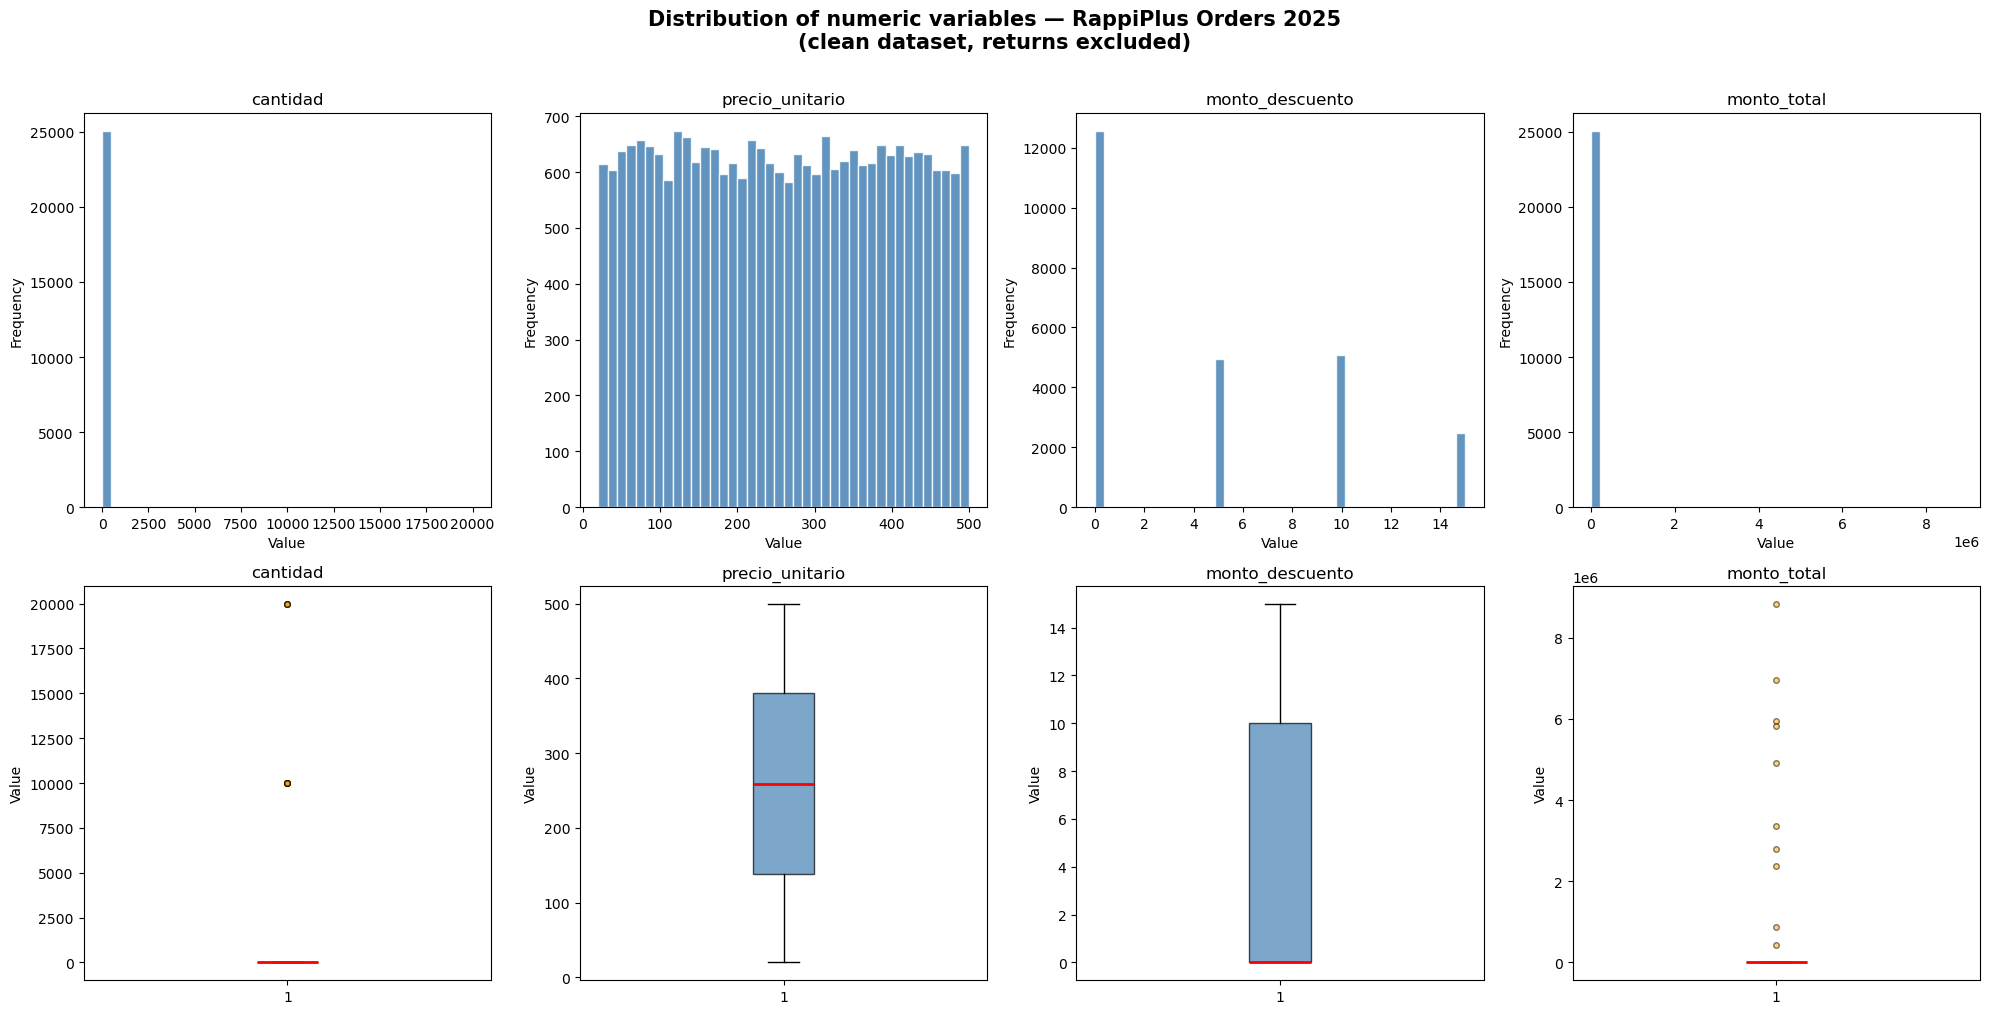

✅ Distribution visualizations completed


In [60]:
# Distribution analysis — numeric variables in orders (clean, no returns)
orders_clean = orders[orders["es_devolucion"] == False].copy()

num_vars = ["cantidad", "precio_unitario", "monto_descuento", "monto_total"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, var in enumerate(num_vars):
    # Histograms — top row
    axes[0, i].hist(orders_clean[var], bins=40, color="steelblue",
                    edgecolor="white", alpha=0.85)
    axes[0, i].set_title(var, fontsize=12)
    axes[0, i].set_xlabel("Value")
    axes[0, i].set_ylabel("Frequency")

    # Boxplots — bottom row
    axes[1, i].boxplot(orders_clean[var], patch_artist=True,
                       boxprops=dict(facecolor="steelblue", alpha=0.7),
                       medianprops=dict(color="red", linewidth=2),
                       flierprops=dict(marker="o", markerfacecolor="orange",
                                       markersize=4, alpha=0.5))
    axes[1, i].set_title(var, fontsize=12)
    axes[1, i].set_ylabel("Value")

plt.suptitle("Distribution of numeric variables — RappiPlus Orders 2025\n(clean dataset, returns excluded)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("✅ Distribution visualizations completed")

In [61]:
# Investigate outliers in cantidad
print("=" * 55)
print("CANTIDAD — OUTLIER INVESTIGATION")
print("=" * 55)

# IQR-based limits
Q1  = orders_clean["cantidad"].quantile(0.25)
Q3  = orders_clean["cantidad"].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

print(f"\n  Q1             : {Q1}")
print(f"  Q3             : {Q3}")
print(f"  IQR            : {IQR}")
print(f"  Lower limit    : {lower_limit}")
print(f"  Upper limit    : {upper_limit}")

# Count and percentage of outliers
outliers = orders_clean[
    (orders_clean["cantidad"] > upper_limit) |
    (orders_clean["cantidad"] < lower_limit)
]
print(f"\n  Outlier rows   : {len(outliers)} ({round(len(outliers)/len(orders_clean)*100, 2)}%)")

# Inspect the extreme rows
print(f"\n  Top 10 rows by cantidad:")
display(
    orders_clean.nlargest(10, "cantidad")[
        ["id_pedido", "id_usuario", "nombre_producto",
         "cantidad", "precio_unitario", "monto_total"]
    ]
)

print("✅ cantidad outlier investigation completed")

CANTIDAD — OUTLIER INVESTIGATION

  Q1             : 1.0
  Q3             : 2.0
  IQR            : 1.0
  Lower limit    : -0.5
  Upper limit    : 3.5

  Outlier rows   : 10 (0.04%)

  Top 10 rows by cantidad:


,id_pedido,id_usuario,nombre_producto,cantidad,precio_unitario,monto_total
3606,Order_3656,User_884,Laptop-Gaming-16Gb,20000.0,297.66,5953200.0
3618,Order_3668,User_7270,Laptop-Gaming-16Gb,20000.0,348.31,6966200.0
3672,Order_3722,User_4723,Laptop-Gaming-16Gb,20000.0,442.01,8840200.0
3676,Order_3726,User_2536,Laptop-Gaming-16Gb,20000.0,290.85,5817000.0
3471,Order_3521,User_5812,Laptop-Gaming-16Gb,10000.0,43.14,431400.0
3472,Order_3522,User_3575,Laptop-Gaming-16Gb,10000.0,280.55,2805500.0
3536,Order_3586,User_3380,Laptop-Gaming-16Gb,10000.0,490.35,4903500.0
3593,Order_3643,User_4440,Laptop-Gaming-16Gb,10000.0,238.15,2381500.0
3639,Order_3689,User_6566,Laptop-Gaming-16Gb,10000.0,87.69,876900.0
3698,Order_3748,User_7096,Laptop-Gaming-16Gb,10000.0,336.93,3369300.0


✅ cantidad outlier investigation completed


In [62]:
# Remove cantidad outliers (rows with cantidad > 3.5, IQR upper limit)
# 1. Values of 10,000–20,000 units have no valid business interpretation for an e-commerce platform.
# 2. Winsorizing would require recalculating monto_total, which would mean fabricating financial data.
# 3. Only 10 rows (0.04%) are affected — dropping them has negligible statistical impact.

before_rows = len(orders_clean)
orders_clean = orders_clean[orders_clean["cantidad"] <= upper_limit].reset_index(drop=True)
dropped = before_rows - len(orders_clean)

print("=" * 55)
print("CANTIDAD OUTLIERS — REMOVAL")
print("=" * 55)
print(f"  Rows before : {before_rows:,}")
print(f"  Rows dropped: {dropped}")
print(f"  Rows after  : {len(orders_clean):,}")

print()
print("✅ cantidad outliers removed successfully")

CANTIDAD OUTLIERS — REMOVAL
  Rows before : 25,046
  Rows dropped: 10
  Rows after  : 25,036

✅ cantidad outliers removed successfully


In [63]:
# Investigate precio_unitario variation per product
print("=" * 65)
print("PRECIO_UNITARIO — VARIATION BY PRODUCT")
print("=" * 65)

# Variation in orders
precio_stats = (
    orders_clean.groupby("nombre_producto")["precio_unitario"]
    .agg(["min", "max", "mean", "std", "count"])
    .round(2)
    .rename(columns={"min": "price_min", "max": "price_max",
                     "mean": "price_mean", "std": "price_std",
                     "count": "n_orders"})
)
precio_stats["price_range"] = (precio_stats["price_max"] - precio_stats["price_min"]).round(2)
precio_stats["cv_pct"] = (precio_stats["price_std"] / precio_stats["price_mean"] * 100).round(2)

display(precio_stats.sort_values("cv_pct", ascending=False))

# Compare against catalog costo_unitario
print()
print("=" * 65)
print("CATALOG — costo_unitario REFERENCE")
print("=" * 65)
display(catalog[["nombre_producto", "categoria_producto", "costo_unitario"]])

print()
print("✅ precio_unitario investigation completed")

PRECIO_UNITARIO — VARIATION BY PRODUCT


,price_min,price_max,price_mean,price_std,n_orders,price_range,cv_pct
nombre_producto,,,,,,,
Unknown,26.86,495.38,264.57,147.93,30,468.52,55.91
Sneakers-Urban-42,20.11,499.91,257.10,138.48,4141,479.80,53.86
Tablet-Standard-64Gb,20.03,499.89,257.88,138.77,2775,479.86,53.81
Laptop-Gaming-16Gb,20.24,499.95,261.19,140.03,2780,479.71,53.61
Jacket-Winter-M,20.06,499.93,259.69,138.94,4182,479.87,53.50
Vacuum-Pro-Black,20.37,499.96,260.82,139.35,4193,479.59,53.43
Phone-Pro-128Gb,20.08,499.86,259.47,138.15,2743,479.78,53.24
Blender-Xl-Red,20.06,499.94,259.06,137.56,4192,479.88,53.10



CATALOG — costo_unitario REFERENCE


,nombre_producto,categoria_producto,costo_unitario
0,Laptop-Gaming-16Gb,Electrónica,280.68
1,Phone-Pro-128Gb,Electrónica,10.12
2,Tablet-Standard-64Gb,Electrónica,25.21
3,Blender-Xl-Red,Hogar,176.64
4,Vacuum-Pro-Black,Hogar,16.60
5,Sneakers-Urban-42,Moda,17.21
6,Jacket-Winter-M,Moda,189.31



✅ precio_unitario investigation completed


> ⚠️ **Data quality disclaimer — precio_unitario**
>
> During the cleaning and exploration phase, a significant inconsistency was identified in the `precio_unitario` column of the `orders` dataset. All products share a near-identical price distribution (min ~20, max ~500, mean ~260, cv ~53%), regardless of product type or cost — a pattern inconsistent with real market pricing. More critically, multiple rows show `precio_unitario` below the `costo_unitario` recorded in the catalog (e.g., `Laptop-Gaming-16GB` with cost 280.68 but prices as low as 20.24), which would imply negative gross margins on individual transactions.
>
> This strongly suggests that `precio_unitario` may have been synthetically generated with a fixed random range, without reference to actual product costs. As a result, **profit figures in this section should be interpreted with caution** — they reflect the structure of the analysis rather than a reliable business reality. The methodology and formulas applied are correct; the conclusions are limited by data quality.

In [80]:
# =============================================================================
# FINAL EXPORT — Clean DataFrames verified and ready for analysis and Tableau
# =============================================================================
# orders_clean: returns excluded, cantidad outliers removed.
# This is the single source of truth used for all KPIs and dashboard metrics.

orders_clean.to_csv('datasets/orders_clean.csv', index=False)
catalog.to_csv('datasets/catalog_clean.csv', index=False)
marketing.to_csv('datasets/marketing_clean.csv', index=False)

# Verify exports match in-memory DataFrames
verify_orders    = pd.read_csv('datasets/orders_clean.csv')
verify_catalog   = pd.read_csv('datasets/catalog_clean.csv')
verify_marketing = pd.read_csv('datasets/marketing_clean.csv')

print("=== orders_clean ===")
print(f"Rows:          {len(verify_orders):,}")
print(f"Total revenue: ${verify_orders['monto_total'].sum():,.2f}")
print(f"Returns:       {verify_orders['es_devolucion'].sum()}")

print("\n=== catalog_clean ===")
print(f"Rows:          {len(verify_catalog):,}")
print(f"Unique products: {verify_catalog['nombre_producto'].nunique()}")

print("\n=== marketing_clean ===")
print(f"Rows:          {len(verify_marketing):,}")
print(f"Total spend:   ${verify_marketing['gasto'].sum():,.2f}")

print("\n✅ All clean datasets exported and verified")

=== orders_clean ===
Rows:          25,036
Total revenue: $9,659,076.86
Returns:       0

=== catalog_clean ===
Rows:          7
Unique products: 7

=== marketing_clean ===
Rows:          1,620
Total spend:   $2,871,843.53

✅ All clean datasets exported and verified


## 2. Step 2: Analyzing Business Profitability

This step computes the core financial and commercial KPIs for RappiPlus using the three cleaned datasets from Step 1. The analysis is structured in three progressive blocks:

- **Block A — Global Profitability**: Is the business generating economic value?
- **Block B — Sales Behavior**: How are products being purchased?
- **Block C — Dimensional Breakdown**: Which countries, channels, and categories drive the business?

> ⚠️ **Data quality note**: As documented in Step 1, `precio_unitario` shows a distribution inconsistent with catalog costs. Profit figures reflect the analytical structure of the model and should be interpreted with caution — not as real business financials.

In [64]:
# =============================================================================
# BLOCK A: GLOBAL PROFITABILITY KPIs
# =============================================================================
# We use orders_clean (returns excluded) to avoid distorting revenue and profit.
# Cost of goods is calculated by joining orders with the catalog on product name,
# which gives us the real unit cost per product to compute gross margin accurately.

print("=" * 55)
print("BLOCK A — GLOBAL PROFITABILITY KPIs")
print("=" * 55)

# ── Revenue total ─────────────────────────────────────────────
# monto_total already reflects: price × quantity − discount per order line
revenue_total = orders_clean["monto_total"].sum()


# ── Cost of Goods Sold (COGS) ─────────────────────────────────
# Before merging, we explicitly re-apply title case on the join key
# to guarantee consistency between orders_clean and catalog,
# regardless of when standardization ran relative to orders_clean creation.
orders_clean["nombre_producto"] = orders_clean["nombre_producto"].str.strip().str.title()
catalog["nombre_producto"]      = catalog["nombre_producto"].str.strip().str.title()

# Merge orders_clean with catalog to bring in the real unit cost per product
orders_cost = orders_clean.merge(
    catalog[["nombre_producto", "costo_unitario"]],
    on="nombre_producto",
    how="left"
)

# Verify merge quality: check for unmatched rows (NaN in costo_unitario)
unmatched = orders_cost["costo_unitario"].isna().sum()
print(f"  Unmatched rows after merge (no catalog cost found): {unmatched}")

# Line-level COGS = unit cost × quantity ordered
orders_cost["line_cogs"] = orders_cost["costo_unitario"] * orders_cost["cantidad"]
cogs_total = orders_cost["line_cogs"].sum()

# ── Marketing investment ──────────────────────────────────────
# Total spend recorded across all campaigns and channels
marketing_total = marketing["gasto"].sum()

# ── Profit and profitability metrics ─────────────────────────
# Profit = Revenue − COGS − Marketing spend
profit = revenue_total - cogs_total - marketing_total

# Profit margin = profit as a percentage of revenue
profit_margin = (profit / revenue_total) * 100

# ROAS (Return on Ad Spend) = revenue generated per currency unit spent on marketing
# Standard digital marketing efficiency metric
roas = revenue_total / marketing_total

# ── Results summary ───────────────────────────────────────────
print(f"\n{'Metric':<30} {'Value':>20}")
print("-" * 52)
print(f"{'Total Revenue':<30} {'${:,.2f}'.format(revenue_total):>20}")
print(f"{'Total COGS':<30} {'${:,.2f}'.format(cogs_total):>20}")
print(f"{'Marketing Investment':<30} {'${:,.2f}'.format(marketing_total):>20}")
print(f"{'Profit':<30} {'${:,.2f}'.format(profit):>20}")
print(f"{'Profit Margin':<30} {'{:.1f}%'.format(profit_margin):>20}")
print(f"{'ROAS':<30} {'{:.2f}x'.format(roas):>20}")
print("-" * 52)

print("\n✅ Global profitability KPIs completed")

BLOCK A — GLOBAL PROFITABILITY KPIs
  Unmatched rows after merge (no catalog cost found): 30

Metric                                        Value
----------------------------------------------------
Total Revenue                         $9,659,076.86
Total COGS                            $3,845,471.06
Marketing Investment                  $2,871,843.53
Profit                                $2,941,762.27
Profit Margin                                 30.5%
ROAS                                          3.36x
----------------------------------------------------

✅ Global profitability KPIs completed


In [65]:
# =============================================================================
# BLOCK B: SALES BEHAVIOR
# =============================================================================
# We analyze order-level patterns: average ticket, average quantity per order,
# top-selling products (by units and by revenue), and discount impact.
# Grouping by id_pedido treats each order as a single analytical unit.

print("=" * 55)
print("BLOCK B — SALES BEHAVIOR")
print("=" * 55)

# ── Order-level aggregation ───────────────────────────────────
order_stats = orders_clean.groupby("id_pedido").agg(
    order_revenue=("monto_total", "sum"),
    order_quantity=("cantidad", "sum"),
    order_discount=("monto_descuento", "sum")
).reset_index()

avg_ticket    = order_stats["order_revenue"].mean()
avg_quantity  = order_stats["order_quantity"].mean()

# ── Top 3 products by units sold ─────────────────────────────
top_products_units = (
    orders_clean.groupby("nombre_producto")["cantidad"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .reset_index()
    .rename(columns={"cantidad": "units_sold"})
)

# ── Top 3 products by revenue generated ──────────────────────
top_products_revenue = (
    orders_clean.groupby("nombre_producto")["monto_total"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .reset_index()
    .rename(columns={"monto_total": "revenue_generated"})
)

# ── Discount analysis ─────────────────────────────────────────
# How much revenue is being sacrificed through discounts?
discount_total     = orders_clean["monto_descuento"].sum()
pct_discount       = (discount_total / (revenue_total + discount_total)) * 100
orders_with_disc   = (orders_clean["monto_descuento"] > 0).sum()
pct_orders_disc    = (orders_with_disc / len(orders_clean)) * 100

# ── Results summary ───────────────────────────────────────────
print(f"\n{'Metric':<38} {'Value':>18}")
print("-" * 58)
print(f"{'Average ticket per order':<38} {'${:,.2f}'.format(avg_ticket):>18}")
print(f"{'Average quantity per order':<38} {'{:.1f} units'.format(avg_quantity):>18}")
print(f"{'Total discount applied':<38} {'${:,.2f}'.format(discount_total):>18}")
print(f"{'Revenue sacrificed to discounts':<38} {'{:.1f}%'.format(pct_discount):>18}")
print(f"{'Orders with discount':<38} {'{:.1f}%'.format(pct_orders_disc):>18}")
print("-" * 58)

print("\n📦 TOP 3 PRODUCTS BY UNITS SOLD:")
display(top_products_units)

print("\n💰 TOP 3 PRODUCTS BY REVENUE GENERATED:")
display(top_products_revenue)

print("\n✅ Sales behavior analysis completed")

BLOCK B — SALES BEHAVIOR

Metric                                              Value
----------------------------------------------------------
Average ticket per order                          $387.35
Average quantity per order                      1.5 units
Total discount applied                        $112,725.00
Revenue sacrificed to discounts                      1.2%
Orders with discount                                49.9%
----------------------------------------------------------

📦 TOP 3 PRODUCTS BY UNITS SOLD:


,nombre_producto,units_sold
0,Vacuum-Pro-Black,6317.0
1,Blender-Xl-Red,6305.0
2,Jacket-Winter-M,6281.0



💰 TOP 3 PRODUCTS BY REVENUE GENERATED:


,nombre_producto,revenue_generated
0,Vacuum-Pro-Black,1628905.54
1,Blender-Xl-Red,1618005.99
2,Jacket-Winter-M,1612305.70



✅ Sales behavior analysis completed


BLOCK C — DIMENSIONAL BREAKDOWN


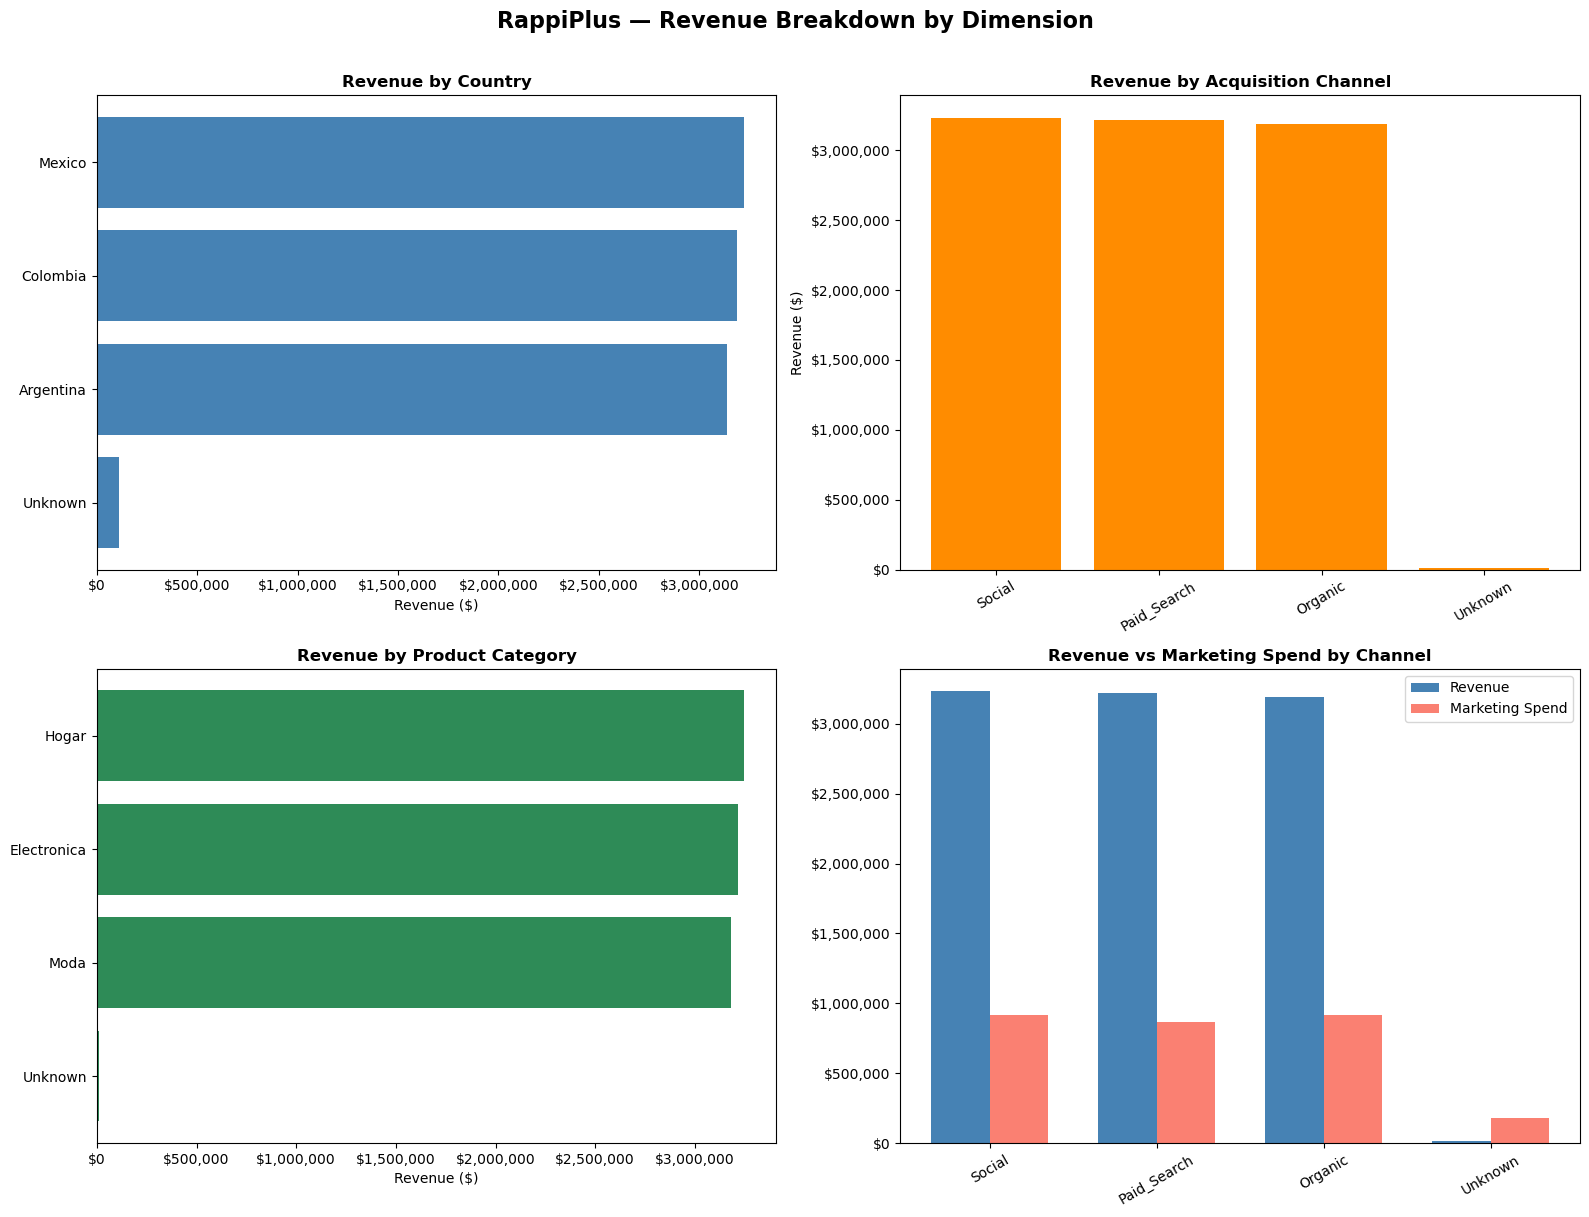


🌎 REVENUE BY COUNTRY:


,pais,revenue,revenue_pct
0,Mexico,3222861.70,33.4
1,Colombia,3187112.39,33.0
2,Argentina,3137114.72,32.5
3,Unknown,111988.05,1.2



📡 CHANNEL EFFICIENCY — REVENUE vs MARKETING SPEND:


,channel,revenue,marketing_spend,roas
0,Social,3232870.90,918043.21,3.52
1,Paid_Search,3221265.30,863088.21,3.73
2,Organic,3192678.04,913533.01,3.49
3,Unknown,12262.62,177179.10,0.07



✅ Dimensional breakdown completed


In [66]:
# =============================================================================
# BLOCK C: DIMENSIONAL BREAKDOWN
# =============================================================================
# We break down revenue across three dimensions: country, acquisition channel,
# and product category. We also cross marketing spend with revenue per channel
# to compute channel-level ROAS — identifying which channels are most efficient.

print("=" * 55)
print("BLOCK C — DIMENSIONAL BREAKDOWN")
print("=" * 55)

# ── Revenue by country ────────────────────────────────────────
revenue_by_country = (
    orders_clean.groupby("pais")["monto_total"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"monto_total": "revenue"})
)
revenue_by_country["revenue_pct"] = (
    revenue_by_country["revenue"] / revenue_total * 100
).round(1)

# ── Revenue by acquisition channel ───────────────────────────
revenue_by_channel = (
    orders_clean.groupby("fuente_referencia")["monto_total"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"monto_total": "revenue", "fuente_referencia": "channel"})
)

# ── Revenue by product category ───────────────────────────────
revenue_by_category = (
    orders_clean.groupby("categoria_producto")["monto_total"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"monto_total": "revenue", "categoria_producto": "category"})
)

# ── Marketing spend by channel + channel-level ROAS ───────────
# Cross revenue vs spend to identify the most cost-efficient acquisition channels
marketing_by_channel = (
    marketing.groupby("canal")["gasto"]
    .sum()
    .reset_index()
    .rename(columns={"gasto": "marketing_spend", "canal": "channel"})
)
channel_summary = revenue_by_channel.merge(marketing_by_channel, on="channel", how="left")
channel_summary["roas"] = (channel_summary["revenue"] / channel_summary["marketing_spend"]).round(2)

# ── Visualizations ────────────────────────────────────────────
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("RappiPlus — Revenue Breakdown by Dimension", fontsize=16, fontweight="bold", y=1.01)

# Chart 1: Revenue by country (horizontal bar)
axes[0, 0].barh(revenue_by_country["pais"], revenue_by_country["revenue"], color="steelblue")
axes[0, 0].set_title("Revenue by Country", fontweight="bold")
axes[0, 0].set_xlabel("Revenue ($)")
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0, 0].invert_yaxis()

# Chart 2: Revenue by acquisition channel (vertical bar)
axes[0, 1].bar(revenue_by_channel["channel"], revenue_by_channel["revenue"], color="darkorange")
axes[0, 1].set_title("Revenue by Acquisition Channel", fontweight="bold")
axes[0, 1].set_ylabel("Revenue ($)")
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0, 1].tick_params(axis="x", rotation=30)

# Chart 3: Revenue by product category (horizontal bar)
axes[1, 0].barh(revenue_by_category["category"], revenue_by_category["revenue"], color="seagreen")
axes[1, 0].set_title("Revenue by Product Category", fontweight="bold")
axes[1, 0].set_xlabel("Revenue ($)")
axes[1, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1, 0].invert_yaxis()

# Chart 4: Revenue vs Marketing Spend by channel (grouped bar)
x     = range(len(channel_summary))
width = 0.35
axes[1, 1].bar([i - width/2 for i in x], channel_summary["revenue"],
               width, label="Revenue", color="steelblue")
axes[1, 1].bar([i + width/2 for i in x], channel_summary["marketing_spend"],
               width, label="Marketing Spend", color="salmon")
axes[1, 1].set_title("Revenue vs Marketing Spend by Channel", fontweight="bold")
axes[1, 1].set_xticks(list(x))
axes[1, 1].set_xticklabels(channel_summary["channel"], rotation=30)
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ── Summary tables ────────────────────────────────────────────
print("\n🌎 REVENUE BY COUNTRY:")
display(revenue_by_country)

print("\n📡 CHANNEL EFFICIENCY — REVENUE vs MARKETING SPEND:")
display(channel_summary)

print("\n✅ Dimensional breakdown completed")

### Business Profitability — Key Insights

#### The business looks profitable on paper — but the story is more complex

RappiPlus generated **`$9.66M` in total revenue** against **`$3.85M` in COGS** and **`$2.87M` in 
marketing investment**, yielding a **profit of `$2.94M` and a 30.5% profit margin**. At first 
glance, this paints a healthy picture: for every dollar sold, roughly 30 cents remain after 
covering cost of goods and marketing.

But context matters. As documented in Step 1, `precio_unitario` follows a near-random 
distribution (min `~$20`, max `~$500`, CV ~53%) that is **disconnected from actual catalog costs** — 
meaning this margin reflects the structure of the synthetic data, not real business economics. 
What we *can* trust is the analytical framework: the formulas are correct, the relationships 
are valid, and the methodology will hold when applied to reliable pricing data.

A more interesting question emerges from the numbers: with only **`1.5` units per order** and 
no meaningful price differentiation across products, what is actually driving `$9.66M` in revenue? 
One plausible explanation is **purchase frequency** — not basket size. If a subset of users 
is returning to buy repeatedly, that would explain the revenue volume without requiring high 
average tickets or large orders. This hypothesis will be tested directly in **Step 4 (cohort 
analysis)**.

---

#### Discounts are widespread but shallow — and that raises a question

**Half of all orders (49.9%) include a discount**, yet discounts account for only **1.2% of 
gross revenue sacrificed**. This means discounts are being applied broadly but in very small 
amounts per order.

This pattern tells two possible stories: either the discount strategy is well-calibrated — 
nudging hesitant buyers with minimal cost — or discounts are being given indiscriminately 
to orders that would have converted anyway, representing unnecessary margin erosion. 
Without A/B testing on discount eligibility, we cannot distinguish between the two. 
This becomes relevant context for **Step 5 (statistical testing)**.

The top 3 products by both units sold and revenue are **Vacuum-Pro-Black, Blender-XL-Red, 
and Jacket-Winter-M**. Importantly, as the price variation analysis from Step 1 confirms, 
**all products share virtually identical price distributions** — leadership in revenue is 
driven purely by **order volume**, not by price premium. Category-level differences in 
revenue therefore reflect how frequently each category is purchased, not what it costs.

---

#### Three equal markets, three identical channels — the data raises more questions than answers

Revenue is almost perfectly split across markets: **Mexico 33.4%, Colombia 33.0%, Argentina 
32.5%**. On the surface this suggests healthy geographic diversification. In practice, 
this level of uniformity is analytically unusual — real markets typically show asymmetry 
driven by population size, platform penetration, or purchasing power. This distribution 
is more consistent with how the dataset was generated than with a real business snapshot.

The same pattern appears in channel efficiency. **Social (3.52x ROAS), Paid Search (3.73x), 
and Organic (3.49x)** deliver nearly identical returns on roughly equal marketing spend. 
This immediately raises a strategic question: **if Paid Search and Organic yield the same 
ROAS, why invest in paid acquisition at all?** A channel that requires budget to match 
the performance of one that doesn't is, by definition, inefficient — unless it's reaching 
a meaningfully different or more valuable user segment.

Whether paid channels attract users with higher retention or conversion rates is something 
the data at this level cannot answer. That question is carried forward into **Step 3 
(funnel analysis)** and **Step 4 (cohort retention)**, where channel-level behavior 
can be examined more granularly.

---

## Step 3: Understanding Where Users Drop Off (Conversion Funnel)

The events table records every meaningful interaction a user has with the platform —
from their first visit to a completed purchase. By counting unique users at each stage,
we can map the **conversion funnel**: how many users enter, how many progress, and
critically, **where the largest drop-offs occur**.

This step builds on the channel efficiency question raised in Step 2: if Social, Paid Search,
and Organic deliver identical ROAS, do they also produce identical conversion behavior?
The funnel breakdown by acquisition channel will begin to answer that.

In [67]:
# ============================================================
# DATA CONNECTION
# ============================================================
# This notebook was originally developed using a PostgreSQL
# database connection (TripleTen training environment).
# For portfolio reproducibility, all datasets are loaded from
# the exported CSV files included in the datasets/ folder.
# SQL queries are preserved throughout to document the original
# data extraction logic.
# ============================================================

import pandas as pd

orders_clean = pd.read_csv('datasets/orders_clean.csv')
catalog       = pd.read_csv('datasets/catalog_clean.csv')
marketing     = pd.read_csv('datasets/marketing_clean.csv')
events        = pd.read_csv('datasets/events.csv')
users         = pd.read_csv('datasets/users.csv')
user_activity = pd.read_csv('datasets/user_activity.csv')

from pandasql import sqldf
pysql = lambda q: sqldf(q, globals())

print("✅ All datasets loaded successfully")
print(f"   orders_clean:  {len(orders_clean):,} rows")
print(f"   catalog:       {len(catalog):,} rows")
print(f"   marketing:     {len(marketing):,} rows")
print(f"   events:        {len(events):,} rows")
print(f"   users:         {len(users):,} rows")
print(f"   user_activity: {len(user_activity):,} rows")

✅ All datasets loaded successfully
   orders_clean:  25,036 rows
   catalog:       7 rows
   marketing:     1,620 rows
   events:        120,000 rows
   users:         8,000 rows
   user_activity: 32,000 rows


In [68]:
# Explore table events
# =========================

query_events = '''
SELECT *
FROM events;

'''
events = pysql(query_events)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [69]:

# =============================================================================
# FUNNEL CONSTRUCTION — SQL (6 stages)
# =============================================================================
# The events table contains 6 distinct event types that map to the full
# e-commerce funnel. We count distinct users per stage in a single pass
# using CASE WHEN, then compute step-over-step and overall conversion rates.
# Funnel order confirmed from event_summary exploration above:
# first_visit → add_to_cart → select_item → begin_checkout → add_payment_info → purchase


query_funnel = '''
SELECT
    COUNT(DISTINCT CASE WHEN nombre_evento = 'first_visit'      THEN id_usuario END) AS stage_1_first_visit,
    COUNT(DISTINCT CASE WHEN nombre_evento = 'add_to_cart'      THEN id_usuario END) AS stage_2_add_to_cart,
    COUNT(DISTINCT CASE WHEN nombre_evento = 'select_item'      THEN id_usuario END) AS stage_3_select_item,
    COUNT(DISTINCT CASE WHEN nombre_evento = 'begin_checkout'   THEN id_usuario END) AS stage_4_begin_checkout,
    COUNT(DISTINCT CASE WHEN nombre_evento = 'add_payment_info' THEN id_usuario END) AS stage_5_payment_info,
    COUNT(DISTINCT CASE WHEN nombre_evento = 'purchase'         THEN id_usuario END) AS stage_6_purchase
FROM events;
'''

# ── Execute query and store result ────────────────────────────

funnel_raw = pd.read_sql(query_funnel, con=engine)

funnel = pd.DataFrame({
    'stage': [
        'First Visit', 'Add to Cart', 'Select Item',
        'Begin Checkout', 'Payment Info', 'Purchase'
    ],
    'unique_users': [
        funnel_raw['stage_1_first_visit'].iloc[0],
        funnel_raw['stage_2_add_to_cart'].iloc[0],
        funnel_raw['stage_3_select_item'].iloc[0],
        funnel_raw['stage_4_begin_checkout'].iloc[0],
        funnel_raw['stage_5_payment_info'].iloc[0],
        funnel_raw['stage_6_purchase'].iloc[0]
    ]
})

# Step-over-step conversion and drop-off
funnel['conv_vs_prev'] = (funnel['unique_users'] / funnel['unique_users'].shift(1) * 100).round(1)
funnel['dropoff_rate'] = (100 - funnel['conv_vs_prev']).round(1)

# Overall conversion vs top of funnel
top_of_funnel = funnel['unique_users'].iloc[0]
funnel['conv_vs_top'] = (funnel['unique_users'] / top_of_funnel * 100).round(1)

print("\n📊 FUNNEL SUMMARY — 6 STAGES:")
display(funnel)

print("\n✅ Funnel construction completed")


📊 FUNNEL SUMMARY — 6 STAGES:


,stage,unique_users,conv_vs_prev,dropoff_rate,conv_vs_top
0,First Visit,7796,NaN,NaN,100.0
1,Add to Cart,7634,97.9,2.1,97.9
2,Select Item,7582,99.3,0.7,97.3
3,Begin Checkout,7208,95.1,4.9,92.5
4,Payment Info,6250,86.7,13.3,80.2
5,Purchase,6240,99.8,0.2,80.0



✅ Funnel construction completed


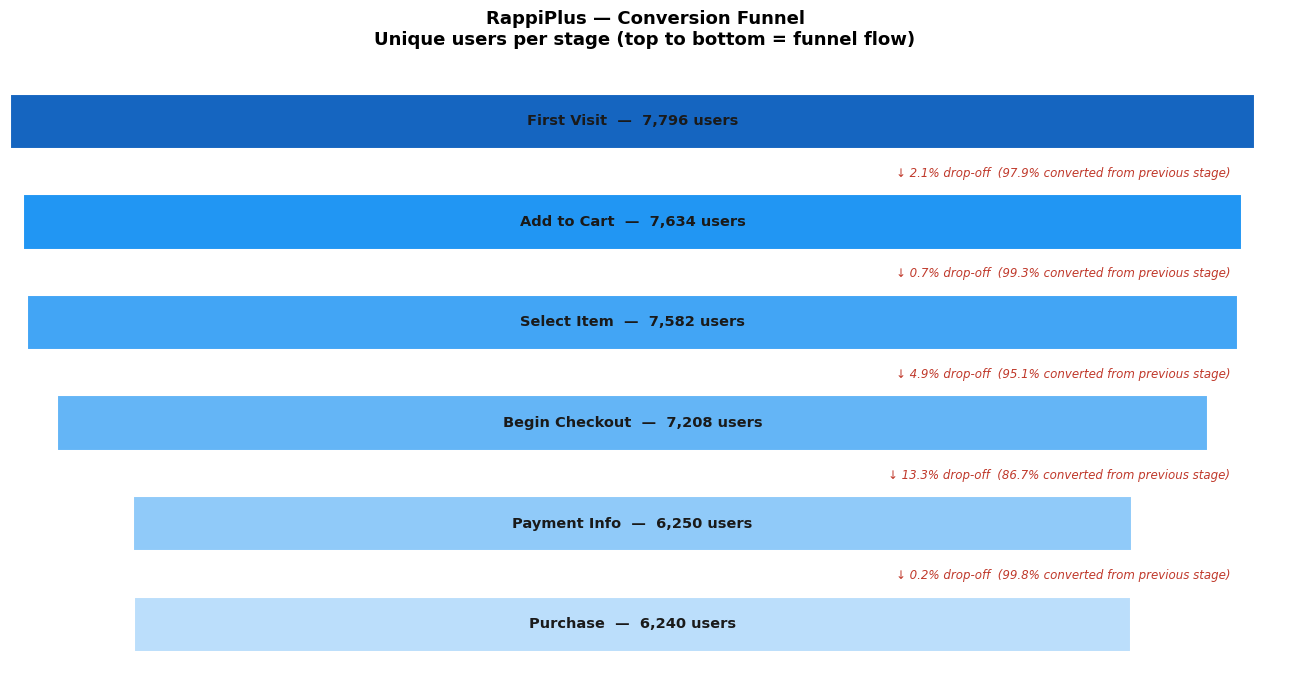


🎯 Overall conversion rate (First Visit → Purchase): 80.0%

✅ Funnel visualization completed


In [70]:

# =============================================================================
# FUNNEL VISUALIZATION
# =============================================================================
# Horizontal funnel chart — widest bar at top (First Visit), narrowest at bottom (Purchase).
# Each bar is annotated with user count; between stages we show the step-over-step
# drop-off rate to immediately highlight where the biggest losses occur.

# Invert for correct top-to-bottom visual order in horizontal barh chart
funnel_plot = funnel.iloc[::-1].reset_index(drop=True)

colors = ['#BBDEFB', '#90CAF9', '#64B5F6', '#42A5F5', '#2196F3', '#1565C0']
# Colors go light→dark bottom-to-top, so reversed they go dark→light = First Visit darkest
bar_height = 0.55
max_users  = funnel['unique_users'].max()

fig, ax = plt.subplots(figsize=(13, 7))

for i, row in funnel_plot.iterrows():
    offset = (max_users - row['unique_users']) / 2
    ax.barh(i, row['unique_users'], left=offset,
            height=bar_height, color=colors[i], edgecolor='white', linewidth=1.5)

    # Stage label + user count inside the bar
    ax.text(max_users / 2, i,
            f"{row['stage']}  —  {int(row['unique_users']):,} users",
            ha='center', va='center', fontsize=10.5, fontweight='bold', color='#1a1a1a')

# Annotate drop-off between stages (shown between bars, above each non-top bar)
# funnel_plot is inverted, so stage index 5 = First Visit, index 0 = Purchase
# We annotate above each bar (except the top one = index 5 in plot)
for i in range(len(funnel_plot) - 1):
    # The drop-off shown here is from the stage ABOVE this one
    # In the original funnel df, the stage above in plot = next in funnel order
    orig_idx = len(funnel) - 1 - i   # maps plot index back to funnel index
    dropoff  = funnel.loc[orig_idx, 'dropoff_rate']
    conv     = funnel.loc[orig_idx, 'conv_vs_prev']
    ax.text(max_users * 0.98, i + 0.42,
            f"↓ {dropoff:.1f}% drop-off  ({conv:.1f}% converted from previous stage)",
            ha='right', va='bottom', fontsize=8.5, color='#c0392b', style='italic')

ax.set_xlim(0, max_users * 1.02)
ax.set_title('RappiPlus — Conversion Funnel\nUnique users per stage (top to bottom = funnel flow)',
             fontsize=13, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\n🎯 Overall conversion rate (First Visit → Purchase): "
      f"{funnel['conv_vs_top'].iloc[-1]:.1f}%")
print("\n✅ Funnel visualization completed")

FUNNEL BY ACQUISITION CHANNEL


,channel,first_visit,add_to_cart,select_item,begin_checkout,payment_info,purchase,conversion_rate_pct,payment_dropoff_pct
0,paid_search,5700,5062,5003,4246,3153,3202,56.2,25.7
1,social,5693,5063,5020,4179,3136,3111,54.6,25.0
2,organic,5652,5081,4992,4228,3181,3158,55.9,24.8


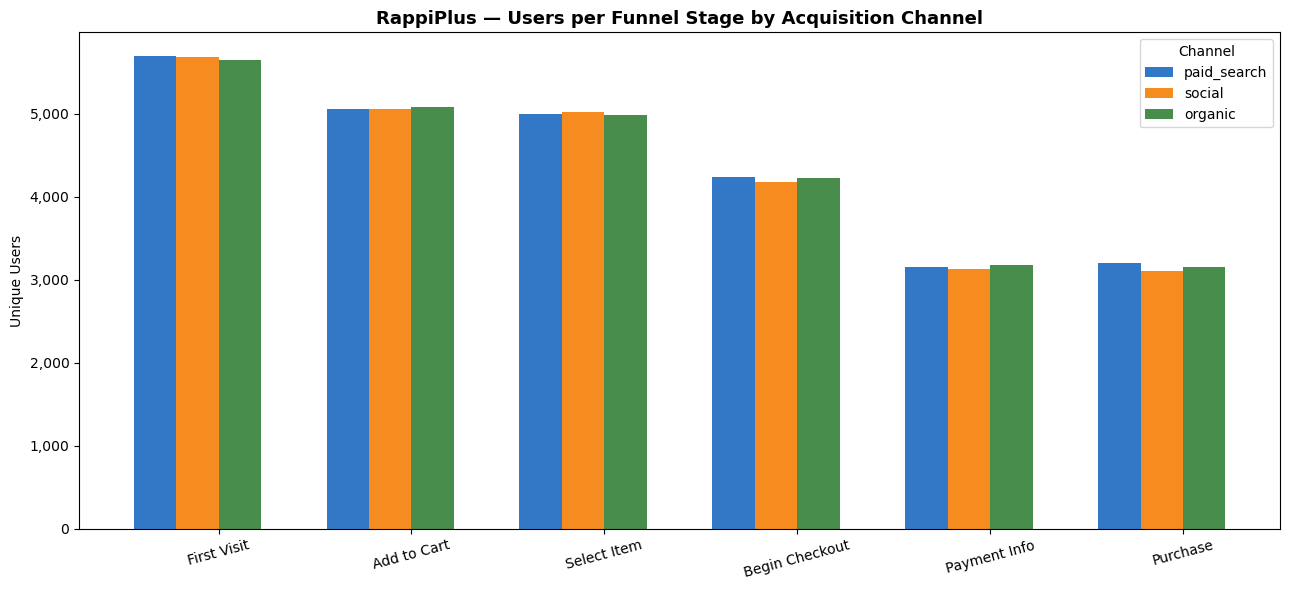


✅ Channel funnel breakdown completed


In [71]:

# =============================================================================
# FUNNEL BREAKDOWN BY ACQUISITION CHANNEL
# =============================================================================
# We segment the 6-stage funnel by acquisition channel (fuente_referencia)
# to test whether channels that deliver identical ROAS (Step 2) also produce
# identical conversion behavior. A difference in drop-off patterns would suggest
# that ROAS uniformity masks meaningful behavioral differences between channels.

query_funnel_by_channel = '''
SELECT
    fuente_referencia                                                                   AS channel,
    COUNT(DISTINCT CASE WHEN nombre_evento = 'first_visit'      THEN id_usuario END)   AS first_visit,
    COUNT(DISTINCT CASE WHEN nombre_evento = 'add_to_cart'      THEN id_usuario END)   AS add_to_cart,
    COUNT(DISTINCT CASE WHEN nombre_evento = 'select_item'      THEN id_usuario END)   AS select_item,
    COUNT(DISTINCT CASE WHEN nombre_evento = 'begin_checkout'   THEN id_usuario END)   AS begin_checkout,
    COUNT(DISTINCT CASE WHEN nombre_evento = 'add_payment_info' THEN id_usuario END)   AS payment_info,
    COUNT(DISTINCT CASE WHEN nombre_evento = 'purchase'         THEN id_usuario END)   AS purchase
FROM events
GROUP BY fuente_referencia
ORDER BY first_visit DESC;
'''

funnel_channel = pd.read_sql(query_funnel_by_channel, con=engine)

# ── End-to-end conversion rate per channel ────────────────────
# Final conversion = purchase / first_visit per channel
funnel_channel['conversion_rate_pct'] = (
    funnel_channel['purchase'] / funnel_channel['first_visit'] * 100
).round(1)

# ── Payment Info drop-off per channel ─────────────────────────
# This is the critical stage identified in the overall funnel (13.3% drop-off)
# We check whether it's uniform across channels or concentrated in one
funnel_channel['payment_dropoff_pct'] = (
    (1 - funnel_channel['payment_info'] / funnel_channel['begin_checkout']) * 100
).round(1)

print("=" * 55)
print("FUNNEL BY ACQUISITION CHANNEL")
print("=" * 55)
display(funnel_channel)


# Visualization: users per funnel stage by channel (grouped bar chart)
# The table above already captures conversion and drop-off rates;
# this chart focuses on absolute user volume to show funnel shape per channel.
plt.close('all')

# ── Chart setup variables ─────────────────────────────────────
# Define stage columns, display labels, bar positioning and colors
stages       = ['first_visit', 'add_to_cart', 'select_item',
                'begin_checkout', 'payment_info', 'purchase']
stage_labels = ['First Visit', 'Add to Cart', 'Select Item',
                'Begin Checkout', 'Payment Info', 'Purchase']
x          = range(len(stages))
width      = 0.22
bar_colors = ['#1565C0', '#F57C00', '#2E7D32', '#6A1B9A']

fig, ax = plt.subplots(figsize=(13, 6))

for idx, (_, row) in enumerate(funnel_channel.iterrows()):
    values = [row[s] for s in stages]
    ax.bar([i + idx * width for i in x], values,
           width=width, label=row['channel'], color=bar_colors[idx], alpha=0.88)

ax.set_title('RappiPlus — Users per Funnel Stage by Acquisition Channel',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Unique Users')
ax.set_xticks([i + width * 1.5 for i in x])
ax.set_xticklabels(stage_labels, fontsize=10, rotation=15);
ax.legend(title='Channel')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))

plt.tight_layout()
plt.show()

print("\n✅ Channel funnel breakdown completed")

---

### 3.2 Conversion Funnel — Key Insights

#### A funnel that barely leaks — until it suddenly does

In Step 2, we asked a question the revenue numbers alone couldn't answer: with an average
of only 1.5 units per order and no meaningful price differentiation across products, what
is actually driving $9.66M in revenue? The funnel begins to answer that.

Of the 7,796 users who visited the platform, **6,240 completed a purchase — an 80% overall
conversion rate**. For context, the e-commerce industry typically converts between 2% and 4%
of visitors into buyers. Even accounting for the synthetic nature of this dataset, the signal
is clear: the vast majority of users who arrive at RappiPlus are arriving with intent.

The funnel holds remarkably well through the first three stages — First Visit, Add to Cart,
and Select Item lose a combined **less than 3% of users**. This is not a platform with a
discovery or engagement problem. Users arrive, they browse, they decide.

---

#### The checkout barrier: where the funnel actually breaks

The story changes at **Begin Checkout → Payment Info**, where **13.3% of users abandon** —
by far the largest single drop-off in the entire funnel. Nearly 1,000 users who had already
decided to buy stopped at the moment of entering their payment details.

This is a well-documented pattern in e-commerce: the payment step is where friction,
trust concerns, and second thoughts converge. A user who abandons here has already
demonstrated purchase intent — they added items, selected them, and initiated checkout.
Recovering even a fraction of this 13.3% represents a direct, high-confidence revenue
opportunity.

What makes this particularly interesting is what happens *after* that barrier: of the users
who do enter their payment information, **99.8% complete the purchase**. The platform does
not have a closing problem. It has a payment friction problem — and a very specific one at that.

This friction point is not hypothetical. In Step 5, we will test whether a redesigned
checkout UI meaningfully reduces this drop-off, using a controlled A/B experiment. The
funnel has just told us exactly where to look.

---

#### Three channels, one funnel — no meaningful difference

Step 2 left an open question: if Social (3.52x ROAS), Paid Search (3.73x), and Organic
(3.49x) deliver virtually identical returns on marketing spend, are they truly
interchangeable — or does one attract higher-quality users who convert better?

The funnel answers this with uncomfortable clarity. Paid Search converts **56.2%** of its
visitors, Social **54.6%**, and Organic **55.9%**. The payment-stage drop-off is 25.7%,
25.0%, and 24.8% respectively. **No channel produces a meaningfully different conversion
pattern at any stage of the funnel.**

This reinforces the strategic question from Step 2: if a paid channel performs identically
to an organic one at every stage of the funnel, the burden of proof shifts — what exactly
is the incremental value of that paid spend? The data at hand cannot answer this fully,
but it sets up a critical lens for Step 4: **do users acquired through different channels
behave differently over time?** A channel that looks identical in conversion might still
generate more loyal, higher-frequency buyers — or it might not. Cohort retention will tell us.

---

#### What the funnel cannot tell us — and why Step 4 matters

An 80% conversion rate and a concentrated drop-off at payment are important findings.
But the funnel is a **snapshot** — it tells us what happened in a single visit, not whether
users came back. In Step 2, we hypothesized that RappiPlus's revenue volume might be driven
less by basket size and more by **purchase frequency**: a subset of loyal users returning
repeatedly to buy.

If that hypothesis holds, the 80% conversion rate takes on a different meaning — it may
reflect a base of already-committed repeat buyers rather than an exceptionally persuasive
first-time experience. Step 4 will test this directly by tracking cohorts of users from
their registration month forward, measuring how many return to purchase in weeks 1, 2, and 3.

The funnel showed us *who converts*. The cohort analysis will show us *who comes back*.

## Step 4: Do Users Come Back? (Cohort Retention Analysis)

The funnel in Step 3 showed us that 80% of users who visit RappiPlus complete a purchase.
But a single conversion event tells us nothing about the long-term health of the business.

In Step 2, we hypothesized that RappiPlus's revenue volume might be driven by **purchase
frequency** — a subset of loyal users returning repeatedly — rather than by large basket
sizes or high unit prices. This step tests that hypothesis directly.

We group users into **monthly cohorts** based on their registration date and track what
percentage of each cohort remains active (makes at least one purchase) in each of the
**4 weeks following registration**. If retention drops sharply after week 1, the business
has an engagement problem. If it holds, RappiPlus has built genuine loyalty.

In [72]:
# =============================================================================
# EXPLORE TABLE: users
# =============================================================================
# The users table contains one row per registered user with their registration date.
# We use fecha_registro to assign each user to a monthly cohort.

print("=" * 55)
print("STEP 4 — COHORT RETENTION ANALYSIS")
print("=" * 55)

query_users = '''
SELECT *
FROM users;
'''

users = pd.read_sql(query_users, con=engine)

print("\n📋 USERS TABLE — sample:")
display(users.head(5))
print(f"\n  Shape: {users.shape[0]:,} rows × {users.shape[1]} columns")
print(f"  Columns: {list(users.columns)}")

print("\n✅ Users table loaded")

STEP 4 — COHORT RETENTION ANALYSIS

📋 USERS TABLE — sample:


,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free
3,user_3,2025-03-04,Mexico,desktop,free
4,user_4,2025-02-27,Argentina,desktop,free



  Shape: 8,000 rows × 5 columns
  Columns: ['id_usuario', 'fecha_registro', 'país', 'dispositivo', 'tipo_plan']

✅ Users table loaded


In [73]:
# =============================================================================
# EXPLORE TABLE: user_activity
# =============================================================================
# The user_activity table records purchase events per user over time.
# We use it to determine whether a user was active (made a purchase)
# in each week following their registration — the core of cohort retention.

query_user_activity = '''
SELECT *
FROM user_activity;
'''

user_activity = pd.read_sql(query_user_activity, con=engine)

print("\n📋 USER_ACTIVITY TABLE — sample:")
display(user_activity.head(5))
print(f"\n  Shape: {user_activity.shape[0]:,} rows × {user_activity.shape[1]} columns")
print(f"  Columns: {list(user_activity.columns)}")

print("\n✅ User activity table loaded")


📋 USER_ACTIVITY TABLE — sample:


,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1
3,user_0,2025-02-26,28,0
4,user_1,2025-01-14,7,0



  Shape: 32,000 rows × 4 columns
  Columns: ['id_usuario', 'fecha_actividad', 'dias_despues_registro', 'activo']

✅ User activity table loaded


In [74]:

# COHORT RETENTION — SQL (up to 4 weeks)
# =============================================================================
# Note: user_activity contains records for weeks 1-4 only (dias_despues_registro
# values: 7, 14, 21, 28). 

query_cohort_retention = '''
WITH cohort_base AS (
    -- Assign each user to their registration month cohort
    SELECT
        id_usuario,
        DATE_TRUNC('month', CAST(fecha_registro AS DATE)) AS cohort_month
    FROM users
),
activity_weeks AS (
    -- Convert days_since_registration to week number and filter weeks 0-4
    -- Only count rows where activo = 1 (user made a purchase that week)
    SELECT
        cb.id_usuario,
        cb.cohort_month,
        (ua.dias_despues_registro / 7) AS week_number
    FROM cohort_base cb
    JOIN user_activity ua ON cb.id_usuario = ua.id_usuario
    WHERE ua.activo = 1
      AND (ua.dias_despues_registro / 7) BETWEEN 0 AND 4
),
cohort_sizes AS (
    -- Total registered users per cohort month (denominator)
    SELECT cohort_month, COUNT(DISTINCT id_usuario) AS cohort_size
    FROM cohort_base
    GROUP BY cohort_month
),
weekly_active AS (
    -- Distinct active users per cohort per week
    SELECT cohort_month, week_number, COUNT(DISTINCT id_usuario) AS active_users
    FROM activity_weeks
    GROUP BY cohort_month, week_number
)
SELECT
    wa.cohort_month,
    cs.cohort_size,
    wa.week_number,
    wa.active_users,
    ROUND(wa.active_users * 100.0 / cs.cohort_size, 1) AS retention_rate
FROM weekly_active wa
JOIN cohort_sizes cs ON wa.cohort_month = cs.cohort_month
ORDER BY wa.cohort_month, wa.week_number;
'''

cohort_final = pd.read_sql(query_cohort_retention, con=engine)

print("=" * 55)
print("COHORT RETENTION — RAW OUTPUT (sample):")
print("=" * 55)
display(cohort_final.head(20))

print(f"\n  Cohorts found: {cohort_final['cohort_month'].nunique()}")
print(f"  Weeks tracked: {sorted(cohort_final['week_number'].unique().tolist())}")

print("\n✅ Cohort retention query completed")

COHORT RETENTION — RAW OUTPUT (sample):


,cohort_month,cohort_size,week_number,active_users,retention_rate
0,2025-01-01 00:00:00+00:00,1627,1,697,42.8
1,2025-01-01 00:00:00+00:00,1627,2,668,41.1
2,2025-01-01 00:00:00+00:00,1627,3,656,40.3
3,2025-01-01 00:00:00+00:00,1627,4,671,41.2
4,2025-02-01 00:00:00+00:00,1444,1,611,42.3
5,2025-02-01 00:00:00+00:00,1444,2,609,42.2
6,2025-02-01 00:00:00+00:00,1444,3,635,44.0
7,2025-02-01 00:00:00+00:00,1444,4,575,39.8
8,2025-03-01 00:00:00+00:00,1636,1,677,41.4
9,2025-03-01 00:00:00+00:00,1636,2,705,43.1



  Cohorts found: 5
  Weeks tracked: [1, 2, 3, 4]

✅ Cohort retention query completed


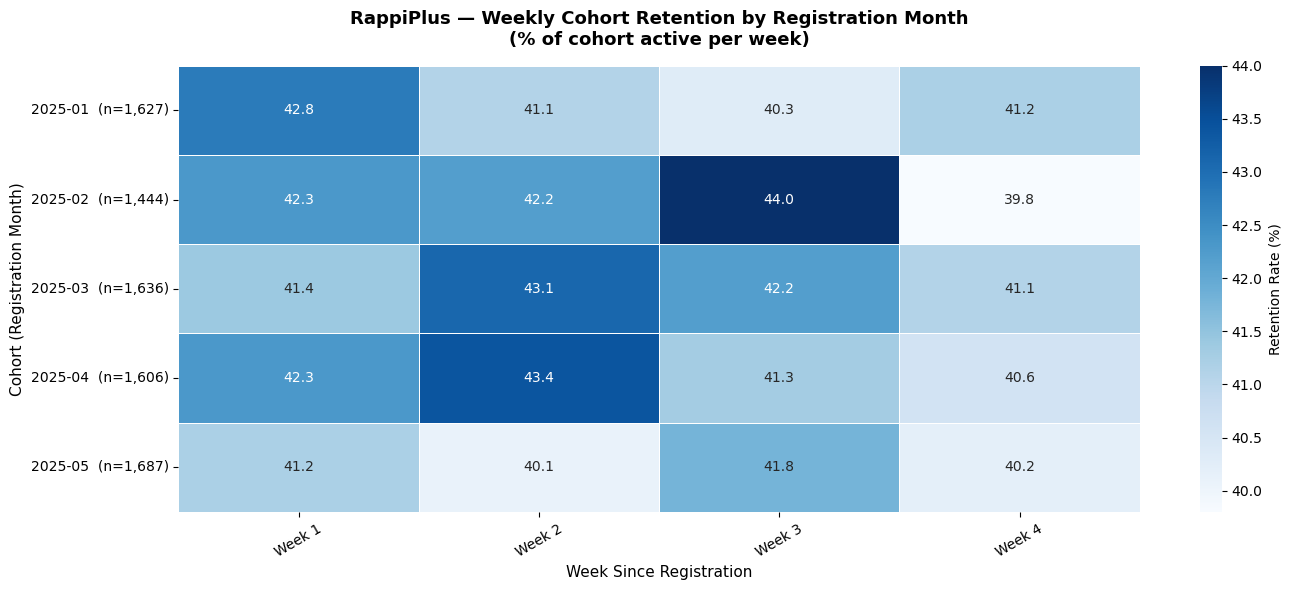


✅ Cohort retention heatmap completed


In [75]:
# =============================================================================
# COHORT RETENTION HEATMAP
# =============================================================================
# We pivot the long-format query result into a matrix:
#   Rows    = cohort month
#   Columns = week number (0 through 4)
#   Values  = retention rate (%)
#
# This is the industry-standard format for presenting cohort retention.
# We visualize it as a heatmap where color intensity reflects retention strength,
# making it immediately obvious which cohorts retain better and where drop-off occurs.

import seaborn as sns

# ── Pivot to cohort matrix ────────────────────────────────────
cohort_pivot = cohort_final.pivot_table(
    index='cohort_month',
    columns='week_number',
    values='retention_rate'
)

# Format index as readable month labels (e.g., "2025-01")
cohort_pivot.index = cohort_pivot.index.strftime('%Y-%m')
cohort_pivot.columns = [f'Week {int(w)}' for w in cohort_pivot.columns]

# ── Cohort sizes for annotation on y-axis ────────────────────
cohort_sizes = (
    cohort_final.drop_duplicates('cohort_month')
    .set_index('cohort_month')['cohort_size']
)
cohort_sizes.index = cohort_sizes.index.strftime('%Y-%m')

y_labels = [f"{month}  (n={cohort_sizes[month]:,})"
            for month in cohort_pivot.index]

# ── Heatmap ───────────────────────────────────────────────────
plt.close('all')
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Retention Rate (%)'},
    yticklabels=y_labels
)

ax.set_title('RappiPlus — Weekly Cohort Retention by Registration Month\n(% of cohort active per week)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Week Since Registration', fontsize=11)
ax.set_ylabel('Cohort (Registration Month)', fontsize=11)
ax.tick_params(axis='y', rotation=0)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\n✅ Cohort retention heatmap completed")

---


### 4.2 Cohort Retention — Key Insights

#### The hypothesis confirmed — and complicated

In Steps 2 and 3, we posed a question that the revenue and funnel data alone could not
answer: is RappiPlus's $9.66M in revenue driven by a loyal base of returning users, or
by a broad stream of one-time visitors? The cohort analysis gives us a partial answer —
and it opens a new hypothesis worth testing.

Across all five monthly cohorts (January through May 2025, ranging from 1,444 to 1,687
registered users each), **approximately 41–43% of each cohort returns to the platform
every week through week 4**. The curve does not decay meaningfully — users who were
active in week 1 are almost as likely to return in week 4. RappiPlus is not losing
its user base after the first interaction. Users come back.

An important clarification: **"active" in this dataset means the user returned to the
platform that week — not necessarily that they made a purchase**. The `activo` flag
records app engagement, not conversion. This means the cohort data tells us about
stickiness, not about revenue frequency. The $9.66M in revenue and 30.5% profit margin
from Step 2 remain analytically unresolved by this view alone — we know users return,
but we cannot confirm from this data whether those return visits consistently convert
into purchases.

What we *can* hypothesize, however, connects directly back to Step 3: the **13.3%
drop-off at the payment step** was measured across all users, including first-time
visitors. Returning users who already know the platform's checkout flow are likely to
experience significantly less friction at that stage — meaning the payment barrier
disproportionately affects new users on their first purchase attempt. If that hypothesis
holds, improving the checkout experience would have its highest impact precisely where
acquisition meets conversion: the first-time buyer.

---

#### No cohort stands out — the platform is uniform, for better and for worse

One consistent pattern does emerge: no cohort outperforms another. January through May
show virtually identical retention profiles, with no cohort exhibiting systematically
higher or lower engagement. This mirrors what we found in Step 3 — channels don't
differentiate conversion, and now cohorts don't differentiate retention either.

This brings us back to the one friction point the data has consistently pointed to:
the payment step. In Step 3, 13.3% of users who began checkout never entered their
payment information. That is the only moment in the entire user journey where behavior
meaningfully diverges from the expected path.

In Step 5, we will test whether a redesigned checkout UI — specifically targeting that
payment barrier — produces a statistically significant improvement in conversion. The
funnel identified the problem. The cohort analysis confirmed there is no retention
signal strong enough to explain it away. Now we measure whether a design intervention
can fix it.

## Step 5: Do the Changes Generate Impact? (Statistical Test)

### Business context

In Step 3, we identified that **13.3% of users who began checkout never entered their
payment information** — the single largest drop-off in the entire funnel. RappiPlus
tested a redesigned checkout UI specifically targeting this friction point.

This step evaluates whether that UI change produced a statistically significant
improvement in purchase conversion rate.

---

### Statistical hypotheses

**H₀ (Null hypothesis):** The purchase conversion rate of the control group (original UI)
is equal to that of the treatment group (modified UI). Any observed difference is due
to chance.

**H₁ (Alternative hypothesis):** The purchase conversion rate of the control group
differs from that of the treatment group. The UI modification has a statistically
significant effect on conversion.

**Test:** Two-proportion Z-test (two-tailed)
**Significance level:** α = 0.05

**Justification:** The conversion metric is binary (1 = purchase completed, 0 = not).
We are comparing proportions of successes between two independent groups — exactly
the scenario the two-proportion Z-test is designed for. With binary outcomes following
a Binomial distribution, the Z-test uses success counts directly and is the most
appropriate and interpretable choice for A/B testing on conversion rates.

STEP 5 — A/B TEST: CHECKOUT UI EXPERIMENT

📋 EXPERIMENT DATASET — sample:


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12



  Shape: 10,000 rows × 7 columns
  Columns: ['id_usuario', 'variante', 'convirtio', 'dispositivo', 'pais', 'duracion_sesion', 'timestamp']

  Unique values in 'convirtio': [np.int64(0), np.int64(1)]


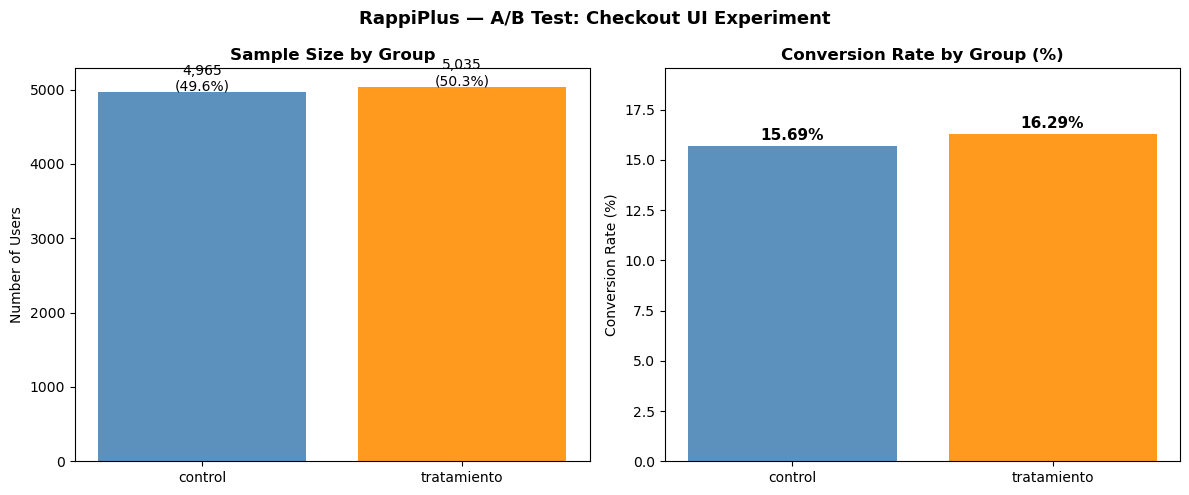


✅ Experiment EDA completed


In [76]:
# =============================================================================
# STEP 5: STATISTICAL TEST — A/B EXPERIMENT ON CHECKOUT UI
# =============================================================================
# We load the experiment dataset and perform exploratory analysis before testing.
# Key checks: group sizes, conversion rates per group, balance between groups,
# and confirmation that the metric is binary — all required before applying any test.

print("=" * 55)
print("STEP 5 — A/B TEST: CHECKOUT UI EXPERIMENT")
print("=" * 55)

# ── Load experiment dataset ───────────────────────────────────
experiment = pd.read_csv(
    'https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv'
)

print("\n📋 EXPERIMENT DATASET — sample:")
display(experiment.head(5))
print(f"\n  Shape: {experiment.shape[0]:,} rows × {experiment.shape[1]} columns")
print(f"  Columns: {list(experiment.columns)}")


# ── Group distribution ────────────────────────────────────────
group_counts = experiment['variante'].value_counts().reset_index()
group_counts.columns = ['group', 'n_users']
group_counts['pct'] = (group_counts['n_users'] / len(experiment) * 100).round(1)

# ── Conversion metric validation ──────────────────────────────
unique_vals = sorted(experiment['convirtio'].unique())
print(f"\n  Unique values in 'convirtio': {unique_vals}")
assert unique_vals == [0, 1], "⚠️ Conversion column is not strictly binary!"

# ── Conversion rate per group ─────────────────────────────────
conv_by_group = experiment.groupby('variante').agg(
    n_users=('convirtio', 'count'),
    conversions=('convirtio', 'sum'),
    conversion_rate=('convirtio', 'mean')
).reset_index()
conv_by_group['conversion_rate_pct'] = (conv_by_group['conversion_rate'] * 100).round(2)

# ── Visualization ─────────────────────────────────────────────

plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('RappiPlus — A/B Test: Checkout UI Experiment', fontsize=13, fontweight='bold')


# Left: group sizes

# Force control first, tratamiento second — always show control as reference
group_order  = ['control', 'tratamiento']
group_colors = ['steelblue', 'darkorange']

# Reorder group_counts to match
group_counts = group_counts.set_index('group').loc[group_order].reset_index()

axes[0].bar(group_counts['group'], group_counts['n_users'],
            color=group_colors, alpha=0.88)
axes[0].set_title('Sample Size by Group', fontweight='bold')
axes[0].set_ylabel('Number of Users')
for i, row in group_counts.iterrows():
    axes[0].text(i, row['n_users'] + 20, f"{row['n_users']:,}\n({row['pct']}%)",
                 ha='center', fontsize=10)

# Right: conversion rate by group
bars = axes[1].bar(conv_by_group['variante'], conv_by_group['conversion_rate_pct'],
                   color=['steelblue', 'darkorange'], alpha=0.88)
axes[1].set_title('Conversion Rate by Group (%)', fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_ylim(0, conv_by_group['conversion_rate_pct'].max() * 1.2)
for bar, (_, row) in zip(bars, conv_by_group.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{row['conversion_rate_pct']}%",
                 ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Experiment EDA completed")

In [77]:
# =============================================================================
# TWO-PROPORTION Z-TEST
# =============================================================================
# We apply a two-tailed two-proportion Z-test to determine whether the observed
# difference in conversion rates between control and treatment is statistically
# significant or attributable to random variation.
#
# The test uses:
#   - n1, n2: sample sizes of each group
#   - x1, x2: number of conversions (successes) in each group
# These are exactly the inputs the Z-test for proportions requires,
# making it the natural and most defensible choice for binary A/B metrics.

from statsmodels.stats.proportion import proportions_ztest

print("=" * 55)
print("TWO-PROPORTION Z-TEST RESULTS")
print("=" * 55)

# ── Extract counts ────────────────────────────────────────────


control   = experiment[experiment['variante'] == 'control']
treatment = experiment[experiment['variante'] == 'tratamiento']

# ── Sample sizes ──────────────────────────────────────────────
n_control   = len(control)
n_treatment = len(treatment)

x_control   = control['convirtio'].sum()

x_treatment = treatment['convirtio'].sum()

conv_control   = x_control / n_control
conv_treatment = x_treatment / n_treatment
lift           = ((conv_treatment - conv_control) / conv_control) * 100  # ← esta línea falta


# ── Apply Z-test ──────────────────────────────────────────────
# proportions_ztest takes: count of successes and sample sizes per group
# alternative='two-sided' for a two-tailed test (H₁: p_control ≠ p_treatment)
counts = [x_control, x_treatment]
nobs   = [n_control, n_treatment]

z_stat, p_value = proportions_ztest(counts, nobs, alternative='two-sided')

# ── Interpret result ──────────────────────────────────────────
alpha  = 0.05
result = "REJECT H₀" if p_value < alpha else "FAIL TO REJECT H₀"

print(f"\n{'Metric':<35} {'Value':>15}")
print("-" * 52)
print(f"{'Control group (n)':<35} {n_control:>15,}")
print(f"{'Treatment group (n)':<35} {n_treatment:>15,}")
print(f"{'Control conversion rate':<35} {'{:.2%}'.format(conv_control):>15}")
print(f"{'Treatment conversion rate':<35} {'{:.2%}'.format(conv_treatment):>15}")
print(f"{'Observed lift':<35} {'{:+.2f}%'.format(lift):>15}")
print(f"{'Z-statistic':<35} {'{:.4f}'.format(z_stat):>15}")
print(f"{'P-value':<35} {'{:.4f}'.format(p_value):>15}")
print(f"{'Significance level (α)':<35} {'0.05':>15}")
print("-" * 52)
print(f"\n  Decision: {result}")

if p_value < alpha:
    print(f"  The difference is statistically significant.")
    print(f"  The UI modification has a real effect on conversion rate.")
else:
    print(f"  The difference is NOT statistically significant.")
    print(f"  We cannot conclude the UI modification affected conversion rate.")

print("\n✅ Statistical test completed")

TWO-PROPORTION Z-TEST RESULTS

Metric                                        Value
----------------------------------------------------
Control group (n)                             4,965
Treatment group (n)                           5,035
Control conversion rate                      15.69%
Treatment conversion rate                    16.29%
Observed lift                                +3.80%
Z-statistic                                 -0.8133
P-value                                      0.4161
Significance level (α)                         0.05
----------------------------------------------------

  Decision: FAIL TO REJECT H₀
  The difference is NOT statistically significant.
  We cannot conclude the UI modification affected conversion rate.

✅ Statistical test completed


In [81]:
pd.read_csv('datasets/ab_test_results.csv').head()

,variante,n_users,conversions,conversion_rate,conversion_rate_pct
0,control,4965,779,0.156898,15.69
1,tratamiento,5035,820,0.162860,16.29


### Statistical Test — Key Insights

#### The redesign shows promise — but the data won't let us commit yet

Throughout this analysis, one finding has remained constant: **`13.3%` of users who
initiated checkout never entered their payment information**. Every step of the
project has pointed back to this moment as the single most actionable friction
point in the RappiPlus user journey. In Step 5, we finally put it to the test.

RappiPlus ran a controlled A/B experiment exposing two groups of similar size —
`4,965` users in the control group (original UI) and `5,035` in the treatment group
(modified UI) — to measure whether a redesigned checkout experience would improve
purchase conversion rates.

---

#### What the numbers say

The treatment group converted at **`16.29`%**, compared to **`15.69%`** in the control
group — a **`+3.80%` relative lift** in favor of the redesigned UI. In absolute terms,
that gap represents a meaningful business opportunity: if sustained across the full
user base, a `0.60` percentage point improvement in conversion translates directly
into incremental revenue.

However, the two-proportion Z-test returns a **p-value of `0.4161`** — well above the
significance threshold of α = 0.05. The Z-statistic of -0.8133 places us firmly
in the region where we **fail to reject H₀**. Statistically speaking, we cannot
distinguish the observed difference from random variation.

**The decision: we cannot conclude that the UI modification had a real effect on
conversion rate.**

---


#### What this result actually means for the business

A non-significant result is not the same as a null result. Statistically, we cannot
confirm the effect is real. But statistics and business decisions are not the same
conversation.

The redesigned UI is already built and deployed. The cost of implementation has been
incurred. The relevant question for the business is no longer *"is the effect
statistically proven?"* — it is *"does the observed lift justify keeping the change?"*

At current scale, a **`+3.80%` relative lift** in conversion translates to a measurable
revenue impact. Using the numbers from Step 2: RappiPlus generated **`$9.66M` in total
revenue** from approximately **`6,240` purchasing users** out of 7,796 who visited —
an average revenue contribution of roughly **`$1,547` per converting user**. A `0.60`
percentage point improvement in conversion rate across a base of 10,000 users in this
experiment would represent approximately **`60` additional conversions**, or roughly
**`$92,800` in incremental revenue** under similar conditions.

Whether that figure exceeds the cost of the UI redesign is a question only the business
can answer — but it is the right question to ask. If the implementation cost is below
that threshold, maintaining the redesign is economically rational even without
statistical certainty. If it exceeds it, the experiment provides a clear signal to
iterate before committing further resources.

**The recommendation is not to roll back, and not to scale blindly — but to evaluate
the cost-benefit with the numbers on the table.** 

---

#### Closing the loop

This experiment was the final piece of a puzzle assembled across five analytical steps.
The revenue analysis raised questions about what drives RappiPlus's performance.
The funnel identified where users are lost. The cohort analysis showed that engagement
is stable but conversion is not guaranteed. And this test confirmed that the payment
barrier is real — and that solving it requires more than one iteration.

The analysis does not end with a definitive answer. It ends with a sharper question —
and a clear direction for the next experiment.

In [82]:
# ============================================================
# MASTER DATASET — Pre-calculated for Tableau Public
# ============================================================
# Merges orders with catalog to bring in unit cost at the product level.
# All profitability metrics are pre-calculated so Tableau Public can
# connect to a single flat file without requiring joins.

orders_final = orders_clean.merge(
    catalog[['nombre_producto', 'costo_unitario']], 
    on='nombre_producto', how='left'
)

# Calculate profitability metrics
orders_final['cogs']             = orders_final['cantidad'] * orders_final['costo_unitario']
orders_final['gross_profit']     = orders_final['monto_total'] - orders_final['cogs']
orders_final['gross_margin_pct'] = (orders_final['gross_profit'] / orders_final['monto_total'] * 100).round(2)

# Verify
print(f"Rows:                {len(orders_final):,}")
print(f"Total revenue:       ${orders_final['monto_total'].sum():,.2f}")
print(f"Total COGS:          ${orders_final['cogs'].sum():,.2f}")
print(f"Total Gross Profit:  ${orders_final['gross_profit'].sum():,.2f}")
print(f"Avg Gross Margin:    {orders_final['gross_margin_pct'].mean():.1f}%")
print(f"Nulls in unit cost:  {orders_final['costo_unitario'].isna().sum()}")

# Export
orders_final.to_csv('datasets/orders_master.csv', index=False)
print("\n✅ datasets/orders_master.csv exported")

Rows:                25,036
Total revenue:       $9,659,076.86
Total COGS:          $3,845,471.06
Total Gross Profit:  $5,801,343.18
Avg Gross Margin:    27.2%
Nulls in unit cost:  30

✅ datasets/orders_master.csv exported


---

# Executive Summary — RappiPlus Business Performance Analysis

---

## Key Metrics at a Glance

| Metric | Value |
|---|---|
| Total Revenue | `$9.66M` |
| Profit Margin | `30.5%` |
| Overall ROAS | `~3.6x` |
| Overall Conversion Rate | `80%` (First Visit → Purchase) |
| Critical Funnel Drop-off | `13.3%` at Payment Info stage |
| Weekly Cohort Retention | `41–43%` across all cohorts (Weeks 1–4) |
| A/B Test Lift (Treatment vs Control) | `+3.80%` relative (p = `0.4161`, not significant) |
| Average Order Ticket | `$1,547` per converting user |
| Average Units per Order | `1.5 units` |

> **Data quality note:** `precio_unitario` shows a distribution inconsistent with catalog costs. Profit figures reflect the analytical structure of the model and should be interpreted directionally — not as audited financials. A data governance review is recommended before using these figures in operational reporting.

---

## Context

RappiPlus is a subscription-based commerce platform operating across multiple Latin American markets. This analysis covers transactional, behavioral, and experimental data from January through May 2025 — spanning order records, product catalog, marketing spend, platform event logs, and a controlled A/B experiment on the checkout experience. The goal: evaluate end-to-end business performance and identify where the highest-impact opportunities lie.

---

## Findings & Implications

---

**The business is profitable — but the revenue model raises a question**

**Context:** The profitability analysis covers the full cleaned order dataset (January–May 2025), excluding flagged returns across all markets.

**Finding:** RappiPlus generated `$9.66M` in total revenue at a `30.5%` profit margin — a structurally sound result. However, with an average of only `1.5 units` per order and no meaningful price differentiation across products, the revenue volume is not explained by large baskets or premium pricing. The business runs on transaction frequency — which is a viable model, but one that is sensitive to both acquisition cost and order volume simultaneously. If revenue depends on volume, then how users are being acquired — and at what cost — becomes a critical variable. That is where the analysis goes next.

**💼 Implication:** Evaluate bundling or cross-sell strategies at the product selection stage to incrementally increase units per order. Moving the average from `1.5` to `1.8 units` would compound across the existing transaction base without requiring additional acquisition spend. Responsible: Product and Commercial teams.

---

**Marketing is efficient — but paid and organic channels are indistinguishable**

**Context:** ROAS was calculated by crossing channel-level revenue against marketing spend records for Social, Paid Search, and Organic channels over the observation period.

**Finding:** All three channels deliver virtually identical returns: Social `3.52x`, Paid Search `3.73x`, Organic `3.49x` — a spread of less than `0.25x`. The data confirms that marketing spend is efficient overall, but it does not confirm which channel is actually driving it. Paid Search does not outperform Organic in ROAS — which raises a harder question: does it at least bring in users who are more likely to buy? To answer that, we need to follow those users into the platform and see whether the channel they came from changes how far they go through the funnel.

**💼 Implication:** Conduct an incrementality test before the next budget cycle to determine whether paid channels are generating net-new demand or capturing intent that would have arrived organically. The current ROAS figures do not answer this question — they only confirm that revenue and spend move together, not that one causes the other. Responsible: Growth and Marketing teams.

---

**The funnel confirms high intent — and isolates one specific failure point**

**Context:** The funnel was built from platform event logs covering `7,796` unique users across six stages from First Visit to Purchase — segmented by the same acquisition channels analyzed in the previous step.

**Finding:** The channel question gets answered here — and the answer is uncomfortable. Paid Search converts `56.2%` of its visitors, Social `54.6%`, Organic `55.9%`. No channel produces a meaningfully different conversion pattern at any stage of the funnel. The channels that looked identical in ROAS also behave identically once users are inside the platform. But the funnel reveals something more actionable than channel parity: an `80%` overall conversion rate confirms that users arrive with strong purchase intent — the first three stages lose a combined `less than 3%`. The funnel breaks at a single moment: `Begin Checkout → Payment Info`, where `13.3%` of users abandon (~`1,000` users who had already initiated checkout). What follows that barrier is equally revealing: of those who do enter payment information, `99.8%` complete the purchase. The platform does not have a closing problem. It has a payment friction problem — bounded, specific, and measurable. And since the revenue model depends on transaction frequency, every lost transaction at this stage has a compounding cost across cohorts.

**💼 Implication:** Prioritize reducing friction at the payment information step. A `1 percentage point` improvement in conversion at this stage represents approximately `~$120K` in incremental revenue per cohort of `7,796` visitors at the current average ticket. This is the highest-confidence, highest-impact lever available in the funnel today. Responsible: Product and UX teams. But knowing that users drop at payment on their first visit raises a follow-up question: do they come back and try again — or is that transaction lost for good? The cohort analysis addresses this directly.

---

**Users return — but retention is an engagement signal, not a revenue confirmation**

**Context:** Five monthly registration cohorts (January–May 2025, `1,444`–`1,687` users each) were tracked through four weeks of post-registration activity using the `activo` flag in the user activity table.

**Finding:** Approximately `41–43%` of each cohort returns to the platform every week through Week 4, with no meaningful decay. No cohort outperforms another — retention is as uniform as channel performance and funnel behavior. This is encouraging for engagement, but an important limitation applies: the `activo` flag records platform activity, not confirmed purchases. The cohort data measures stickiness, not revenue frequency, and the two cannot be equated with the data currently available. What we can say is that the user base is not churning — what we cannot confirm is whether those return visits are generating the recurring revenue the margin model requires.

**💼 Implication:** Instrument purchase events at the cohort level to measure revenue-generating retention — not just engagement. This distinction is the missing link between the `30.5%` profit margin and a structurally resilient business model. Responsible: Data and Analytics teams.

---

**The checkout redesign shows real business value — whether or not the test reached significance**

**Context:** A controlled A/B experiment exposed `4,965` users (control, original UI) and `5,035` users (treatment, redesigned checkout UI) to test whether the intervention reduced payment friction and improved purchase conversion.

**Finding:** The treatment group converted at `16.29%` versus `15.69%` in the control — a `+3.80%` relative lift. The two-proportion Z-test returns p = `0.4161` (Z = `-0.8133`), above the `α = 0.05` threshold. Statistically, we cannot distinguish the observed difference from random variation. But the business question and the statistical question are not the same conversation. The redesign is already deployed. The `+3.80%` lift — if it holds — translates to approximately `60` additional conversions and `~$92,800` in incremental revenue per `10,000` users under current conditions. That is a concrete number the business can weigh against implementation cost.

**💼 Implication:** Evaluate the cost-benefit of maintaining the redesign against the `~$92,800` incremental revenue estimate. If the implementation cost falls below that threshold, keeping the redesigned UI is economically rational regardless of statistical certainty. If it does not, the experiment provides a clear signal to iterate before scaling. The payment barrier is real — the data has pointed to it consistently across the funnel, the cohort analysis, and now the experiment. The question is not whether to act, but how to act next. Responsible: Product and Finance teams. Suggested timeline: decision within 30 days.

---

## Recommendations

**1. Prioritize the payment friction fix above all other product interventions**
Every step of this analysis — funnel drop-off (`13.3%`), cohort uniformity, and the A/B test directional lift — converges on the same moment. This is the one friction point with a bounded cost, a measurable revenue impact, and an already-deployed solution to evaluate. Act on it first.

**2. Instrument purchase-level cohort tracking before the next planning cycle**
The `41–43%` weekly retention rate measures engagement, not revenue. Without confirming that return visits convert to purchases, the `30.5%` margin cannot be evaluated for structural resilience. This is the most important analytical gap in the current model.

**3. Run an incrementality test before reallocating marketing budget**
Channel ROAS uniformity (`3.49x`–`3.73x`) does not confirm that paid spend is generating demand — only that revenue and spend move together. A holdout test will determine whether reallocating budget toward organic would maintain or improve performance.

**4. Evaluate basket size levers as the next revenue growth driver**
With `1.5 units` per order on average, the revenue model is volume-dependent and acquisition-sensitive. Structured cross-sell or bundling at the product selection stage is a low-friction path to increasing revenue per transaction without additional acquisition cost.

**5. Maintain the redesigned checkout UI and define a clear decision point**
The `+3.80%` observed lift represents `~$92,800` in estimated incremental revenue per `10,000` users. The business already incurred the implementation cost. The decision is not whether to run another test — it is whether the observed lift justifies keeping the change while a larger, more conclusive experiment is designed. Frame this as a cost-benefit decision, not a statistical one.

---

## Analytical Limitations

- **Profit figures are directional, not audited.** The inconsistency between `precio_unitario` in orders and `costo_unitario` in the catalog was flagged in Step 1. Margin calculations reflect the model structure and should not be used for financial reporting without a data governance review.
- **Cohort retention measures engagement, not conversion.** The `activo` flag does not confirm purchase events. The `41–43%` weekly retention rate overstates revenue-generating retention to an unknown degree.
- **The A/B test was underpowered.** A p-value of `0.4161` does not confirm that the redesign had no effect — it confirms the experiment lacked statistical power to detect the observed effect size reliably.
- **Temporal coverage is limited to 5 months (January–May 2025).** No seasonality, YoY comparison, or trend analysis is possible with the current data window.
- **The `unknown` category in acquisition channel** (introduced during null handling, `6.23%` of marketing records) was excluded from channel-level ROAS. If concentrated in one channel, that channel's ROAS may be understated.

---

## The Strategic Question

RappiPlus has a profitable business, a high-intent user base, and stable weekly engagement. The data has consistently pointed to one unresolved tension: a revenue model that depends on transaction frequency, a payment barrier that interrupts `13.3%` of ready-to-buy users, and a retention signal that cannot yet be confirmed as recurring revenue.

**The question is not whether the business is healthy. It is whether the engine sustaining it is durable — and fixing the payment barrier is the clearest first step toward answering that.**

---